# IMU IK to ID Comparison (JinWoo_MT_IK)

This notebook runs inference from IMU-derived IK angles using `runs_0507_all/best_model.pt` (with fallback to `runs/0507_ik_id_all/best_model.pt`) and compares model outputs against OpenSim inverse dynamics.

Pipeline used here:
- Angle input: **6 Hz zero-phase low-pass**, 4th order
- Angular velocity input: **15 Hz zero-phase low-pass**, 4th order
- Model output: **6 Hz zero-phase low-pass**, 4th order

Because the MTw IK pickle files do not include timestamps, alignment is done by sample index over the shared trial duration.

In [1]:
import sys
import warnings
import pickle
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt, find_peaks
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore", message=".*NumPy.*")

In [2]:
# Paths
PROJECT_ROOT = Path('/home/metamobility3/Jinwoo/os_kinetics')
IMU_IK_ROOT = Path('/home/metamobility3/Jinwoo/mt_processed')
IMU_IK_METHOD = 'Xsens'
OPENSIM_ROOT = Path('/home/metamobility3/Jinwoo')
TELEMETRY_ROOT = PROJECT_ROOT

# User-requested checkpoint path, with robust fallback to current repo structure
CHECKPOINT_CANDIDATES = [
    PROJECT_ROOT / 'runs/0512_ik_id_all_zero_in_zero_out' / 'best_model.pt'
]
CHECKPOINT = next((p for p in CHECKPOINT_CANDIDATES if p.exists()), None)
if CHECKPOINT is None:
    raise FileNotFoundError(f'No checkpoint found in candidates: {CHECKPOINT_CANDIDATES}')

# Filter specs (requested)
ANGLE_CUTOFF_HZ = 6.0
VEL_CUTOFF_HZ = 6.0 # 15.0
OUT_CUTOFF_HZ = 6.0
FILTER_ORDER = 4

# Data assumptions
DEFAULT_FS_HZ = 100.0  # used when timestamps are unavailable (IMU IK pkl)
PREFERRED_EXO_FOLDER = 'awinda'

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

sys.path.insert(0, str(PROJECT_ROOT))
from dataset import IK_DOF_NAMES
from model import TCN, TransformerMoment, GaussianDiffusion1D

print(f'Checkpoint: {CHECKPOINT}')
print(f'Device: {DEVICE}')
print(f'IMU IK root: {IMU_IK_ROOT} | method: {IMU_IK_METHOD}')

Checkpoint: /home/metamobility3/Jinwoo/os_kinetics/runs/0512_ik_id_all_zero_in_zero_out/best_model.pt
Device: cuda


In [3]:
def parse_opensim_table(path: Path) -> pd.DataFrame:
    with open(path, 'r') as f:
        header_end = None
        for i, line in enumerate(f):
            if line.strip().lower() == 'endheader':
                header_end = i
                break
    if header_end is None:
        raise RuntimeError(f'endheader not found: {path}')
    df = pd.read_csv(path, sep=r'\s+', skiprows=header_end + 1)
    return df.set_index('time')


def causal_lpf(x: np.ndarray, fs_hz: float, cutoff_hz: float, order: int = 4) -> np.ndarray:
    """Zero-phase low-pass filter (kept function name for compatibility)."""
    x = np.asarray(x, dtype=np.float64)
    if x.ndim != 1:
        raise ValueError('lpf expects 1D input')
    nyq = 0.5 * fs_hz
    if cutoff_hz <= 0 or cutoff_hz >= nyq or len(x) < 4:
        return x.copy()
    sos = butter(order, cutoff_hz / nyq, btype='low', output='sos')
    try:
        y = sosfiltfilt(sos, x)
    except ValueError:
        # Very short signals can violate filtfilt padding constraints.
        return x.copy()
    return y


def causal_lpf_multichannel(X: np.ndarray, fs_hz: float, cutoff_hz: float, order: int = 4) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    if X.ndim != 2:
        raise ValueError('lpf_multichannel expects (T, C)')
    return np.column_stack([causal_lpf(X[:, c], fs_hz=fs_hz, cutoff_hz=cutoff_hz, order=order) for c in range(X.shape[1])])


def estimate_subject_mass_kg(subject_dir: Path) -> float:
    opensim_dir = subject_dir / 'opensim'
    if not opensim_dir.exists():
        return np.nan
    no_exo = sorted(opensim_dir.glob('*no_exo.osim'))
    if not no_exo:
        return np.nan
    tree = ET.parse(no_exo[0])
    root = tree.getroot()
    masses = []
    for body in root.findall('.//Body'):
        m = body.find('mass')
        if m is not None and m.text:
            try:
                masses.append(float(m.text))
            except ValueError:
                pass
    if not masses:
        for body in root.findall('.//{*}Body'):
            m = body.find('{*}mass')
            if m is not None and m.text:
                try:
                    masses.append(float(m.text))
                except ValueError:
                    pass
    return float(np.sum(masses)) if masses else np.nan


def filename_to_condition(stem: str) -> str:
    speed_token, cond_token = stem.split('_', 1)  # e.g. 0p8mps_lg
    return f'{cond_token.upper()}_{speed_token}'   # -> LG_0p8mps


def find_id_path(subject: str, condition: str) -> tuple[Path, str]:
    subject_dir = OPENSIM_ROOT / subject
    exo_order = [PREFERRED_EXO_FOLDER, 'hip-exo', 'knee-exo']
    for exo in exo_order:
        p = subject_dir / exo / 'id' / f'{condition}_id.sto'
        if p.exists():
            return p, exo
    return None, None


def find_ik_path(subject: str, condition: str, exo_folder: str = None) -> Path:
    subject_dir = OPENSIM_ROOT / subject
    exo_order = [PREFERRED_EXO_FOLDER, 'hip-exo', 'knee-exo']
    if exo_folder in exo_order:
        exo_order = [exo_folder] + [e for e in exo_order if e != exo_folder]

    for exo in exo_order:
        ik_dir = subject_dir / exo / 'ik'
        exact = ik_dir / f'{condition}_ik.mot'
        if exact.exists():
            return exact
        matches = sorted(ik_dir.glob(f'{condition}*_ik.mot')) if ik_dir.exists() else []
        if matches:
            return matches[0]
    return None


def build_mocap_ik_matrix_rad(ik_df: pd.DataFrame) -> np.ndarray:
    pos_deg = np.full((len(ik_df), len(IK_DOF_NAMES)), np.nan, dtype=np.float64)
    for j, name in enumerate(IK_DOF_NAMES):
        if name in ik_df.columns:
            pos_deg[:, j] = ik_df[name].to_numpy(dtype=np.float64)
    return np.deg2rad(pos_deg)


def _subject_token(subject: str) -> str:
    return subject.lower().replace('-', '_')


def _condition_tokens(condition: str) -> tuple[str, str]:
    cond_token, speed_token = condition.lower().split('_', 1)  # lg_0p8mps
    return speed_token, cond_token


def telemetry_npz_path(subject: str, condition: str, exo_type: str) -> Path:
    speed_token, cond_token = _condition_tokens(condition)
    stem = f"{_subject_token(subject)}_{exo_type}_{speed_token}_{cond_token}_exo_on.npz"
    p = TELEMETRY_ROOT / stem
    return p if p.exists() else None


def load_telemetry_torque_lr(npz_path: Path) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    d = np.load(npz_path, allow_pickle=True)
    t = np.asarray(d['time'], dtype=np.float64)

    # Prefer applied torque channels when available; otherwise fall back to commanded torque.
    if 'applied_R' in d and 'applied_L' in d:
        tr = np.asarray(d['applied_R'], dtype=np.float64)
        tl = np.asarray(d['applied_L'], dtype=np.float64)
    elif 'cmd_R' in d and 'cmd_L' in d:
        tr = np.asarray(d['cmd_R'], dtype=np.float64)
        tl = np.asarray(d['cmd_L'], dtype=np.float64)
    else:
        raise KeyError(f'No applied/cmd torque channels found in {npz_path.name}')

    return t, tr, tl


def interp_telemetry_to_sync_time(
    t_sync: np.ndarray,
    t_telemetry: np.ndarray,
    torque_r: np.ndarray,
    torque_l: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    t_sync_rel = np.asarray(t_sync, dtype=np.float64) - float(t_sync[0])
    t_tel_rel = np.asarray(t_telemetry, dtype=np.float64) - float(t_telemetry[0])

    tor_r = np.interp(t_sync_rel, t_tel_rel, torque_r, left=np.nan, right=np.nan)
    tor_l = np.interp(t_sync_rel, t_tel_rel, torque_l, left=np.nan, right=np.nan)

    # Outside telemetry support window -> assume no applied exo torque.
    tor_r = np.where(np.isfinite(tor_r), tor_r, 0.0)
    tor_l = np.where(np.isfinite(tor_l), tor_l, 0.0)
    return tor_r.astype(np.float64), tor_l.astype(np.float64)


def _first_peak_index_above_threshold(
    sig: np.ndarray,
    fs_hz: float,
    threshold_rad: float,
    start_offset_s: float = 0.25,
) -> tuple[int, str]:
    x = np.asarray(sig, dtype=np.float64).copy()
    if x.ndim != 1:
        raise ValueError('_first_peak_index_above_threshold expects 1D signal')

    valid = np.isfinite(x)
    if valid.sum() < 20:
        raise RuntimeError('Signal has too few finite samples for peak detection')

    # Fill sparse NaNs to keep peak finding stable.
    fill_val = float(np.nanmedian(x[valid]))
    x[~valid] = fill_val

    start_idx = min(len(x) - 1, max(0, int(round(start_offset_s * fs_hz))))
    if start_idx >= len(x) - 5:
        start_idx = 0

    span = float(np.nanmax(x) - np.nanmin(x))
    min_prom = max(np.deg2rad(3.0), 0.10 * span)
    min_dist = max(1, int(round(0.3 * fs_hz)))

    peaks, _ = find_peaks(x, prominence=min_prom, distance=min_dist)
    peaks = peaks[(peaks >= start_idx) & (x[peaks] >= threshold_rad)]

    if len(peaks) > 0:
        return int(peaks[0]), 'peaks_above_threshold'

    # Fallback: first threshold crossing after start, if it exists.
    crossing = np.where(x[start_idx:] >= threshold_rad)[0]
    if len(crossing) > 0:
        return int(start_idx + crossing[0]), 'threshold_crossing_fallback'

    raise RuntimeError('No right hip flexion peak above threshold found')


def estimate_lag_from_first_right_hip_peak_above_threshold(
    imu_pos: np.ndarray,
    mocap_pos: np.ndarray,
    fs_hz: float,
    max_lag_samples: int,
    threshold_deg: float = 15.0,
) -> tuple[int, dict]:
    hip_name = 'hip_flexion_r'
    if hip_name not in IK_DOF_NAMES:
        raise RuntimeError('Right hip flexion channel not found in IK_DOF_NAMES')
    hip_idx = IK_DOF_NAMES.index(hip_name)

    threshold_rad = np.deg2rad(float(threshold_deg))
    imu_idx, imu_method = _first_peak_index_above_threshold(
        imu_pos[:, hip_idx], fs_hz=fs_hz, threshold_rad=threshold_rad
    )
    mocap_idx, mocap_method = _first_peak_index_above_threshold(
        mocap_pos[:, hip_idx], fs_hz=fs_hz, threshold_rad=threshold_rad
    )

    lag_samples = int(imu_idx - mocap_idx)
    clipped = False
    if lag_samples > max_lag_samples:
        lag_samples = max_lag_samples
        clipped = True
    elif lag_samples < -max_lag_samples:
        lag_samples = -max_lag_samples
        clipped = True

    info = {
        'hip_channel': IK_DOF_NAMES[hip_idx],
        'peak_threshold_deg': float(threshold_deg),
        'peak_threshold_rad': float(threshold_rad),
        'imu_peak_idx': int(imu_idx),
        'mocap_peak_idx': int(mocap_idx),
        'imu_peak_method': imu_method,
        'mocap_peak_method': mocap_method,
        'lag_clipped': bool(clipped),
    }
    return lag_samples, info


print('Helpers defined.')

Helpers defined.


In [4]:
# Load checkpoint model + metadata
ckpt = torch.load(str(CHECKPOINT), map_location=DEVICE, weights_only=False)
cfg = ckpt['model_config']
model_type = cfg.get('model_type', 'tcn')

if model_type == 'transformer':
    model = TransformerMoment(
        n_input_channels=cfg['n_input_channels'],
        n_output_channels=cfg['n_output_channels'],
        d_model=cfg['d_model'],
        n_heads=cfg['n_heads'],
        n_layers=cfg['n_layers'],
        d_ff=cfg['d_ff'],
        dropout=cfg['dropout'],
    )
elif model_type == 'diffusion':
    model = GaussianDiffusion1D(
        n_input_channels=cfg['n_input_channels'],
        n_output_channels=cfg['n_output_channels'],
        d_model=cfg['d_model'],
        n_heads=cfg['n_heads'],
        n_layers=cfg['n_layers'],
        d_ff=cfg['d_ff'],
        dropout=cfg['dropout'],
        n_timesteps=cfg.get('n_timesteps', 1000),
        schedule=cfg.get('schedule', 'cosine'),
        predict_epsilon=cfg.get('predict_epsilon', True),
        n_inference_steps=cfg.get('n_inference_steps', 50),
    )
else:
    model = TCN(
        n_input_channels=cfg['n_input_channels'],
        n_output_channels=cfg['n_output_channels'],
        hidden_channels=cfg['hidden_channels'],
        n_blocks=cfg['n_blocks'],
        kernel_size=cfg['kernel_size'],
        dropout=cfg['dropout'],
    )

model.load_state_dict(ckpt['model_state_dict'])
model.to(DEVICE)
model.eval()

WINDOW_SIZE = int(ckpt.get('window_size', 100))
INPUT_INDICES = list(ckpt.get('input_indices', [6, 9, 10, 13, 16, 17]))
MOMENT_INDICES = list(ckpt.get('moment_indices', [3, 12, 14, 6, 13, 15]))
DOF_NAMES = list(ckpt.get('dof_names', ['hip_flexion', 'knee_angle', 'ankle_angle']))

# Right/left index split for unilateral-paired inference
H = len(INPUT_INDICES) // 2
INPUT_IDX_R = INPUT_INDICES[:H]
INPUT_IDX_L = INPUT_INDICES[H:]

ID_COLS = [
    'hip_flexion_r_moment',
    'knee_angle_r_moment',
    'ankle_angle_r_moment',
    'hip_flexion_l_moment',
    'knee_angle_l_moment',
    'ankle_angle_l_moment',
]

print('Model config:', cfg)
print('window_size:', WINDOW_SIZE)
print('input_indices:', INPUT_INDICES)
print('moment_indices:', MOMENT_INDICES)
print('DOF names:', DOF_NAMES)

Model config: {'model_type': 'tcn', 'n_input_channels': 6, 'n_output_channels': 3, 'hidden_channels': 80, 'n_blocks': 5, 'kernel_size': 5, 'dropout': 0.1}
window_size: 100
input_indices: [6, 9, 10, 13, 16, 17]
moment_indices: [3, 12, 14, 6, 13, 15]
DOF names: ['hip_flexion', 'knee_angle', 'ankle_angle']


In [5]:
@torch.no_grad()
def causal_infer_one_side(pos_3: np.ndarray, vel_3: np.ndarray) -> np.ndarray:
    """
    pos_3, vel_3: (T, 3), already filtered, radians / rad/s.
    Returns: (T, 3) model output in N·m/kg.
    """
    x = np.concatenate([pos_3, vel_3], axis=1).astype(np.float32)  # (T, 6)
    n = x.shape[0]
    W = WINDOW_SIZE
    c_out = cfg['n_output_channels']

    if n < W:
        raise ValueError(f'Trial too short: n={n}, window={W}')

    pred = np.zeros((n, c_out), dtype=np.float64)

    def _fwd(start: int) -> np.ndarray:
        xw = np.ascontiguousarray(x[start:start + W].T)
        xt = torch.from_numpy(xw).unsqueeze(0).to(DEVICE)
        yw = model(xt).squeeze(0).detach().cpu().numpy().T  # (W, c_out)
        return yw

    # Bootstrap first window
    y0 = _fwd(0)
    pred[:W] = y0

    # Causal rolling: keep newest sample from each subsequent window
    for start in range(1, n - W + 1):
        yw = _fwd(start)
        pred[start + W - 1] = yw[W - 1]

    return pred.astype(np.float32)


def run_bilateral_inference(pos_full: np.ndarray, vel_full: np.ndarray) -> np.ndarray:
    pred_r = causal_infer_one_side(pos_full[:, INPUT_IDX_R], vel_full[:, INPUT_IDX_R])
    pred_l = causal_infer_one_side(pos_full[:, INPUT_IDX_L], vel_full[:, INPUT_IDX_L])
    return np.concatenate([pred_r, pred_l], axis=1)


def build_model_input_from_pkl(imu_dict: dict) -> np.ndarray:
    """Build full IK vector (T, len(IK_DOF_NAMES)) from MTw IK pickle channels (degrees)."""
    n = len(next(iter(imu_dict.values())))
    pos_deg = np.zeros((n, len(IK_DOF_NAMES)), dtype=np.float64)

    key_map = {
        'hip_flexion_r': 'hip_flexion_r',
        'knee_angle_r': 'knee_flexion_r',
        'ankle_angle_r': 'ankle_flexion_r',
        'hip_flexion_l': 'hip_flexion_l',
        'knee_angle_l': 'knee_flexion_l',
        'ankle_angle_l': 'ankle_flexion_l',
    }
    sign_map = {
        'knee_angle_r': -1.0,
        'knee_angle_l': -1.0,
    }

    for ik_name, pkl_name in key_map.items():
        if pkl_name not in imu_dict:
            raise KeyError(f'Missing channel in pkl: {pkl_name}')
        idx = IK_DOF_NAMES.index(ik_name)
        sign = sign_map.get(ik_name, 1.0)
        pos_deg[:, idx] = sign * np.asarray(imu_dict[pkl_name], dtype=np.float64)

    return pos_deg

In [6]:
# Discover candidate trials
records = []
for subj_dir in sorted(IMU_IK_ROOT.glob('AB*')):
    if not subj_dir.is_dir():
        continue
    subject = subj_dir.name
    subj_opensim_dir = OPENSIM_ROOT / subject
    mass_kg = estimate_subject_mass_kg(subj_opensim_dir)

    preferred_ik_dir = subj_dir / 'ik' / IMU_IK_METHOD
    imu_ik_dir = preferred_ik_dir if preferred_ik_dir.exists() else subj_dir
    imu_ik_source = IMU_IK_METHOD if preferred_ik_dir.exists() else 'legacy_flat_subject_dir'

    for pkl_path in sorted(imu_ik_dir.glob('*.pkl')):
        cond = filename_to_condition(pkl_path.stem)
        id_path, exo_folder = find_id_path(subject, cond)
        records.append({
            'subject': subject,
            'pkl_file': pkl_path.name,
            'pkl_path': str(pkl_path),
            'imu_ik_source': imu_ik_source,
            'condition': cond,
            'id_found': id_path is not None,
            'id_path': id_path,
            'exo_folder': exo_folder,
            'mass_kg': mass_kg,
        })

manifest_df = pd.DataFrame(records)
display(manifest_df)

print('Total IMU IK files:', len(manifest_df))
print('Matched with ID:', int(manifest_df['id_found'].sum()) if 'id_found' in manifest_df.columns else 0)
print('Unmatched (will skip):', int((~manifest_df['id_found']).sum()) if 'id_found' in manifest_df.columns else 0)

,subject,pkl_file,condition,id_found,id_path,exo_folder,mass_kg
0,AB01_Jinwoo,0p8mps_lg.pkl,LG_0p8mps,True,/home/metamobility3/Jinwoo/AB01_Jinwoo/awinda/...,awinda,88.0
1,AB01_Jinwoo,0p8mps_ra.pkl,RA_0p8mps,True,/home/metamobility3/Jinwoo/AB01_Jinwoo/awinda/...,awinda,88.0
2,AB01_Jinwoo,0p8mps_rd.pkl,RD_0p8mps,True,/home/metamobility3/Jinwoo/AB01_Jinwoo/awinda/...,awinda,88.0
3,AB01_Jinwoo,1p2mps_lg.pkl,LG_1p2mps,True,/home/metamobility3/Jinwoo/AB01_Jinwoo/awinda/...,awinda,88.0
4,AB01_Jinwoo,1p6mps_lg.pkl,LG_1p6mps,True,/home/metamobility3/Jinwoo/AB01_Jinwoo/awinda/...,awinda,88.0
5,AB02_Oscar,0p8mps_lg.pkl,LG_0p8mps,True,/home/metamobility3/Jinwoo/AB02_Oscar/awinda/i...,awinda,71.1
6,AB02_Oscar,0p8mps_ra.pkl,RA_0p8mps,True,/home/metamobility3/Jinwoo/AB02_Oscar/awinda/i...,awinda,71.1
7,AB02_Oscar,0p8mps_rd.pkl,RD_0p8mps,True,/home/metamobility3/Jinwoo/AB02_Oscar/awinda/i...,awinda,71.1
8,AB02_Oscar,1p2mps_lg.pkl,LG_1p2mps,True,/home/metamobility3/Jinwoo/AB02_Oscar/awinda/i...,awinda,71.1
9,AB02_Oscar,1p6mps_lg.pkl,LG_1p6mps,True,/home/metamobility3/Jinwoo/AB02_Oscar/awinda/i...,awinda,71.1


Total IMU IK files: 20
Matched with ID: 20
Unmatched (will skip): 0


In [7]:
# Run inference + comparison
TRIAL_DATA = {}
rows = []

IK_ALIGN_MAX_LAG_SEC = 30.0

matched_df = manifest_df[manifest_df['id_found']].reset_index(drop=True)
total_trials = len(matched_df)
print(f'Running inference for {total_trials} matched trials...')

for i, row in matched_df.iterrows():
    trial_idx = i + 1
    subject = row['subject']
    pkl_file = row['pkl_file']
    cond = row['condition']
    exo_folder = row['exo_folder']
    id_path = Path(row['id_path'])
    mass_kg = float(row['mass_kg']) if pd.notna(row['mass_kg']) else np.nan
    trial_key = f'{subject}::{cond}'

    print(f'[{trial_idx:02d}/{total_trials:02d}] START {trial_key} ({pkl_file})', flush=True)

    try:
        pkl_path = Path(row['pkl_path']) if 'pkl_path' in row and pd.notna(row['pkl_path']) else (IMU_IK_ROOT / subject / pkl_file)
        imu = pickle.load(open(pkl_path, 'rb'))
        pos_deg = build_model_input_from_pkl(imu)              # (T_imu, 23)
        pos_rad = np.deg2rad(pos_deg)

        mocap_ik_path = find_ik_path(subject, cond, exo_folder=exo_folder)
        if mocap_ik_path is None:
            raise FileNotFoundError(f'Mocap IK not found for {trial_key}')

        # OpenSim timelines
        id_df = parse_opensim_table(id_path)
        ik_df = parse_opensim_table(mocap_ik_path)

        t_id = id_df.index.to_numpy(dtype=np.float64)
        fs_hz = 1.0 / float(np.median(np.diff(t_id))) if len(t_id) > 2 else DEFAULT_FS_HZ

        mocap_pos_rad = build_mocap_ik_matrix_rad(ik_df)

        # Estimate lag from first RIGHT hip-flexion peak above 15 deg.
        # Positive lag means IMU starts later than mocap and is shifted forward.
        imu_pos_for_align = causal_lpf_multichannel(pos_rad, fs_hz=fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ, order=FILTER_ORDER)
        mocap_pos_for_align = causal_lpf_multichannel(mocap_pos_rad, fs_hz=fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ, order=FILTER_ORDER)
        max_lag_samples = int(round(IK_ALIGN_MAX_LAG_SEC * fs_hz))
        lag_samples, peak_info = estimate_lag_from_first_right_hip_peak_above_threshold(
            imu_pos_for_align,
            mocap_pos_for_align,
            fs_hz=fs_hz,
            max_lag_samples=max_lag_samples,
            threshold_deg=15.0,
        )

        start_imu = max(lag_samples, 0)
        start_ref = max(-lag_samples, 0)
        n_sync = min(
            len(pos_rad) - start_imu,
            len(mocap_pos_rad) - start_ref,
            len(t_id) - start_ref,
        )
        if n_sync < WINDOW_SIZE:
            raise RuntimeError(f'Not enough synced samples after lag alignment: {n_sync}')

        pos_rad_sync = pos_rad[start_imu:start_imu + n_sync]
        mocap_pos_rad_sync = mocap_pos_rad[start_ref:start_ref + n_sync]
        t_sync = t_id[start_ref:start_ref + n_sync]

        # Build OpenSim ID matrix (N·m), align to mocap timeline, and apply requested 6 Hz zero-phase LPF.
        id_nm = np.zeros((len(t_id), len(ID_COLS)), dtype=np.float64)
        for c, col in enumerate(ID_COLS):
            id_nm[:, c] = id_df[col].to_numpy(dtype=np.float64) if col in id_df.columns else np.nan
        id_nm_sync = id_nm[start_ref:start_ref + n_sync]

        # Subtract exoskeleton applied torque from Mocap ID before comparison.
        # Hip telemetry drives hip moments; knee telemetry drives knee moments.
        exo_torque_sync = np.zeros_like(id_nm_sync, dtype=np.float64)

        hip_npz_path = telemetry_npz_path(subject, cond, exo_type='hip')
        if hip_npz_path is not None:
            t_tel, tor_r, tor_l = load_telemetry_torque_lr(hip_npz_path)
            tor_r_sync, tor_l_sync = interp_telemetry_to_sync_time(t_sync, t_tel, tor_r, tor_l)
            exo_torque_sync[:, 0] += tor_r_sync  # hip_flexion_r_moment
            exo_torque_sync[:, 3] += tor_l_sync  # hip_flexion_l_moment

        knee_npz_path = telemetry_npz_path(subject, cond, exo_type='knee')
        if knee_npz_path is not None:
            t_tel, tor_r, tor_l = load_telemetry_torque_lr(knee_npz_path)
            tor_r_sync, tor_l_sync = interp_telemetry_to_sync_time(t_sync, t_tel, tor_r, tor_l)
            exo_torque_sync[:, 1] += tor_r_sync  # knee_angle_r_moment
            exo_torque_sync[:, 4] += tor_l_sync  # knee_angle_l_moment

        id_nm_net_sync = id_nm_sync - exo_torque_sync

        # Requested filters: 6 Hz on angle, 15 Hz on velocity, 6 Hz on model output, and 6 Hz on OpenSim ID (all zero-phase, order 4)
        pos_f = causal_lpf_multichannel(pos_rad_sync, fs_hz=fs_hz, cutoff_hz=ANGLE_CUTOFF_HZ, order=FILTER_ORDER)
        vel_raw = np.gradient(pos_f, 1.0 / fs_hz, axis=0)
        vel_f = causal_lpf_multichannel(vel_raw, fs_hz=fs_hz, cutoff_hz=VEL_CUTOFF_HZ, order=FILTER_ORDER)

        pred_nmpkg = run_bilateral_inference(pos_f, vel_f)
        pred_nmpkg_f = causal_lpf_multichannel(pred_nmpkg, fs_hz=fs_hz, cutoff_hz=OUT_CUTOFF_HZ, order=FILTER_ORDER)
        id_nm_f = causal_lpf_multichannel(id_nm_net_sync, fs_hz=fs_hz, cutoff_hz=OUT_CUTOFF_HZ, order=FILTER_ORDER)

        # Convert to N·m when mass is available
        pred_nm_f = pred_nmpkg_f * mass_kg if np.isfinite(mass_kg) else np.full_like(pred_nmpkg_f, np.nan)

        # Shared aligned window
        n_common = min(len(pred_nmpkg_f), len(id_nm_f))
        pred_nmpkg_c = pred_nmpkg_f[:n_common]
        pred_nm_c = pred_nm_f[:n_common]
        id_nm_c = id_nm_f[:n_common]
        t_c = t_sync[:n_common]

        if np.isfinite(mass_kg):
            id_nmpkg_c = id_nm_c / mass_kg
        else:
            id_nmpkg_c = np.full_like(id_nm_c, np.nan)

        # Metrics in N·m/kg (primary) and N·m (if mass available)
        metrics = []
        for c in range(len(ID_COLS)):
            m = {}
            v_kg = np.isfinite(pred_nmpkg_c[:, c]) & np.isfinite(id_nmpkg_c[:, c])
            if v_kg.sum() > 1:
                e_kg = pred_nmpkg_c[v_kg, c] - id_nmpkg_c[v_kg, c]
                corr_kg = np.corrcoef(pred_nmpkg_c[v_kg, c], id_nmpkg_c[v_kg, c])[0, 1]
                m['rmse_nmpkg'] = float(np.sqrt(np.mean(e_kg ** 2)))
                m['r2_nmpkg'] = float(corr_kg ** 2)
            else:
                m['rmse_nmpkg'] = np.nan
                m['r2_nmpkg'] = np.nan

            v_nm = np.isfinite(pred_nm_c[:, c]) & np.isfinite(id_nm_c[:, c])
            if v_nm.sum() > 1:
                e_nm = pred_nm_c[v_nm, c] - id_nm_c[v_nm, c]
                corr_nm = np.corrcoef(pred_nm_c[v_nm, c], id_nm_c[v_nm, c])[0, 1]
                m['rmse_nm'] = float(np.sqrt(np.mean(e_nm ** 2)))
                m['r2_nm'] = float(corr_nm ** 2)
            else:
                m['rmse_nm'] = np.nan
                m['r2_nm'] = np.nan

            metrics.append(m)

        TRIAL_DATA[trial_key] = {
            'subject': subject,
            'condition': cond,
            'pkl_file': pkl_file,
            'id_path': str(id_path),
            'mocap_ik_path': str(mocap_ik_path),
            'hip_telemetry_npz': str(hip_npz_path) if hip_npz_path is not None else None,
            'knee_telemetry_npz': str(knee_npz_path) if knee_npz_path is not None else None,
            'mass_kg': mass_kg,
            'lag_samples': int(lag_samples),
            'lag_seconds': float(lag_samples / fs_hz),
            'align_method': 'first_right_hip_peak_gt15deg',
            'hip_channel': peak_info['hip_channel'],
            'peak_threshold_deg': float(peak_info['peak_threshold_deg']),
            'imu_peak_idx': int(peak_info['imu_peak_idx']),
            'mocap_peak_idx': int(peak_info['mocap_peak_idx']),
            'imu_peak_method': peak_info['imu_peak_method'],
            'mocap_peak_method': peak_info['mocap_peak_method'],
            'lag_clipped': bool(peak_info['lag_clipped']),
            't': t_c,
            'imu_ik_rad': pos_rad_sync[:n_common],
            'mocap_ik_rad': mocap_pos_rad_sync[:n_common],
            'pred_nmpkg': pred_nmpkg_c,
            'pred_nm': pred_nm_c,
            'id_nmpkg': id_nmpkg_c,
            'id_nm': id_nm_c,
            'metrics': metrics,
        }

        rows.append({
            'trial': trial_key,
            'subject': subject,
            'condition': cond,
            'pkl_file': pkl_file,
            'mass_kg': mass_kg,
            'hip_torque_subtracted': bool(hip_npz_path is not None),
            'knee_torque_subtracted': bool(knee_npz_path is not None),
            'align_method': 'first_right_hip_peak_gt15deg',
            'hip_channel': peak_info['hip_channel'],
            'lag_samples': int(lag_samples),
            'lag_seconds': float(lag_samples / fs_hz),
            'peak_threshold_deg': float(peak_info['peak_threshold_deg']),
            'imu_peak_idx': int(peak_info['imu_peak_idx']),
            'mocap_peak_idx': int(peak_info['mocap_peak_idx']),
            'lag_clipped': bool(peak_info['lag_clipped']),
            'n_common': n_common,
            'mean_rmse_nmpkg': float(np.nanmean([m['rmse_nmpkg'] for m in metrics])),
            'mean_r2_nmpkg': float(np.nanmean([m['r2_nmpkg'] for m in metrics])),
            'mean_rmse_nm': float(np.nanmean([m['rmse_nm'] for m in metrics])),
            'mean_r2_nm': float(np.nanmean([m['r2_nm'] for m in metrics])),
        })

        print(
            f'[{trial_idx:02d}/{total_trials:02d}] DONE  {trial_key} '
            f"| lag={lag_samples:+d} samples ({lag_samples / fs_hz:+.3f} s), "
            f"hip={peak_info['hip_channel']} first peak>{peak_info['peak_threshold_deg']:.1f}deg "
            f"(imu={peak_info['imu_peak_idx']}, mocap={peak_info['mocap_peak_idx']}), "
            f"torque_subtract[hip={hip_npz_path is not None}, knee={knee_npz_path is not None}], "
            f'n_common={n_common}',
            flush=True,
        )
    except Exception as e:
        print(f'[{trial_idx:02d}/{total_trials:02d}] FAIL  {trial_key} | {type(e).__name__}: {e}', flush=True)

summary_df = pd.DataFrame(rows).sort_values(['subject', 'condition']).reset_index(drop=True)
display(summary_df)
print('Computed trials:', len(summary_df))

Running inference for 20 matched trials...
[01/20] START AB01_Jinwoo::LG_0p8mps (0p8mps_lg.pkl)


[01/20] FAIL  AB01_Jinwoo::LG_0p8mps | RuntimeError: No right hip flexion peak above threshold found
[02/20] START AB01_Jinwoo::RA_0p8mps (0p8mps_ra.pkl)
[02/20] DONE  AB01_Jinwoo::RA_0p8mps | lag=+778 samples (+7.780 s), hip=hip_flexion_r first peak>15.0deg (imu=1045, mocap=267), torque_subtract[hip=True, knee=True], n_common=2569
[03/20] START AB01_Jinwoo::RD_0p8mps (0p8mps_rd.pkl)
[03/20] DONE  AB01_Jinwoo::RD_0p8mps | lag=+1585 samples (+15.850 s), hip=hip_flexion_r first peak>15.0deg (imu=1822, mocap=237), torque_subtract[hip=False, knee=True], n_common=1866
[04/20] START AB01_Jinwoo::LG_1p2mps (1p2mps_lg.pkl)
[04/20] FAIL  AB01_Jinwoo::LG_1p2mps | RuntimeError: No right hip flexion peak above threshold found
[05/20] START AB01_Jinwoo::LG_1p6mps (1p6mps_lg.pkl)
[05/20] FAIL  AB01_Jinwoo::LG_1p6mps | RuntimeError: No right hip flexion peak above threshold found
[06/20] START AB02_Oscar::LG_0p8mps (0p8mps_lg.pkl)
[06/20] DONE  AB02_Oscar::LG_0p8mps | lag=+1243 samples (+12.430 s), h

,trial,subject,condition,pkl_file,mass_kg,hip_torque_subtracted,knee_torque_subtracted,align_method,hip_channel,lag_samples,lag_seconds,peak_threshold_deg,imu_peak_idx,mocap_peak_idx,lag_clipped,n_common,mean_rmse_nmpkg,mean_r2_nmpkg,mean_rmse_nm,mean_r2_nm
0,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,RA_0p8mps,0p8mps_ra.pkl,88.0,True,True,first_right_hip_peak_gt15deg,hip_flexion_r,778,7.78,15.0,1045,267,False,2569,0.532849,0.001052,46.890683,0.001052
1,AB01_Jinwoo::RD_0p8mps,AB01_Jinwoo,RD_0p8mps,0p8mps_rd.pkl,88.0,False,True,first_right_hip_peak_gt15deg,hip_flexion_r,1585,15.85,15.0,1822,237,False,1866,0.429915,0.000904,37.832560,0.000904
2,AB02_Oscar::LG_0p8mps,AB02_Oscar,LG_0p8mps,0p8mps_lg.pkl,71.1,True,False,first_right_hip_peak_gt15deg,hip_flexion_r,1243,12.43,15.0,1327,84,False,8000,0.140493,0.686827,9.989023,0.686827
3,AB02_Oscar::LG_1p2mps,AB02_Oscar,LG_1p2mps,1p2mps_lg.pkl,71.1,True,False,first_right_hip_peak_gt15deg,hip_flexion_r,291,2.91,15.0,382,91,False,8000,0.155800,0.848803,11.077366,0.848803
4,AB02_Oscar::LG_1p6mps,AB02_Oscar,LG_1p6mps,1p6mps_lg.pkl,71.1,True,False,first_right_hip_peak_gt15deg,hip_flexion_r,263,2.63,15.0,330,67,False,8000,0.223627,0.789418,15.899908,0.789418
5,AB02_Oscar::RA_0p8mps,AB02_Oscar,RA_0p8mps,0p8mps_ra.pkl,71.1,True,True,first_right_hip_peak_gt15deg,hip_flexion_r,292,2.92,15.0,404,112,False,8000,0.201494,0.861189,14.326193,0.861189
6,AB02_Oscar::RD_0p8mps,AB02_Oscar,RD_0p8mps,0p8mps_rd.pkl,71.1,False,True,first_right_hip_peak_gt15deg,hip_flexion_r,760,7.60,15.0,812,52,False,8000,0.197812,0.781019,14.064406,0.781019
7,AB03_Ilseung::LG_0p8mps,AB03_Ilseung,LG_0p8mps,0p8mps_lg.pkl,84.4,True,False,first_right_hip_peak_gt15deg,hip_flexion_r,232,2.32,15.0,377,145,False,6850,0.121606,0.793634,10.263528,0.793634
8,AB03_Ilseung::LG_1p2mps,AB03_Ilseung,LG_1p2mps,1p2mps_lg.pkl,84.4,True,False,first_right_hip_peak_gt15deg,hip_flexion_r,269,2.69,15.0,371,102,False,8000,0.131561,0.888588,11.103709,0.888588
9,AB03_Ilseung::LG_1p6mps,AB03_Ilseung,LG_1p6mps,1p6mps_lg.pkl,84.4,True,False,first_right_hip_peak_gt15deg,hip_flexion_r,228,2.28,15.0,350,122,False,8000,0.162981,0.896927,13.755573,0.896927


Computed trials: 17


In [8]:
# Channel-wise summary table
CHANNELS = [
    'hip_flexion_r', 'knee_angle_r', 'ankle_angle_r',
    'hip_flexion_l', 'knee_angle_l', 'ankle_angle_l',
]

detail_rows = []
for trial, d in TRIAL_DATA.items():
    for c, ch in enumerate(CHANNELS):
        m = d['metrics'][c]
        detail_rows.append({
            'trial': trial,
            'channel': ch,
            'rmse_nmpkg': m['rmse_nmpkg'],
            'r2_nmpkg': m['r2_nmpkg'],
            'rmse_nm': m['rmse_nm'],
            'r2_nm': m['r2_nm'],
        })

detail_df = pd.DataFrame(detail_rows)
display(detail_df)

print('Mean by channel (N·m/kg):')
display(detail_df.groupby('channel')[['rmse_nmpkg', 'r2_nmpkg']].mean().sort_index())

,trial,channel,rmse_nmpkg,r2_nmpkg,rmse_nm,r2_nm
0,AB01_Jinwoo::RA_0p8mps,hip_flexion_r,0.348171,4.389715e-04,30.639024,4.389715e-04
1,AB01_Jinwoo::RA_0p8mps,knee_angle_r,0.798264,1.878407e-03,70.247197,1.878407e-03
2,AB01_Jinwoo::RA_0p8mps,ankle_angle_r,0.672252,1.724185e-03,59.158193,1.724185e-03
3,AB01_Jinwoo::RA_0p8mps,hip_flexion_l,0.353697,8.592007e-05,31.125334,8.592007e-05
4,AB01_Jinwoo::RA_0p8mps,knee_angle_l,0.353062,6.401861e-04,31.069462,6.401861e-04
...,...,...,...,...,...,...
97,AB08_Seokhyun::LG_1p6mps,knee_angle_r,0.686767,1.436568e-04,49.378529,1.436568e-04
98,AB08_Seokhyun::LG_1p6mps,ankle_angle_r,0.856524,2.880641e-04,61.584052,2.880641e-04
99,AB08_Seokhyun::LG_1p6mps,hip_flexion_l,1.164340,7.129185e-05,83.716075,7.129185e-05
100,AB08_Seokhyun::LG_1p6mps,knee_angle_l,0.677462,2.723087e-06,48.709485,2.723087e-06


Mean by channel (N·m/kg):


,rmse_nmpkg,r2_nmpkg
channel,,
ankle_angle_l,0.386737,0.543653
ankle_angle_r,0.404902,0.518810
hip_flexion_l,0.380298,0.504113
hip_flexion_r,0.398390,0.480781
knee_angle_l,0.300497,0.471299
knee_angle_r,0.358940,0.425228


In [9]:
# Interactive trial plot
if not TRIAL_DATA:
    raise RuntimeError('No trials available. Check path mapping and ID availability.')

trial_keys = sorted(TRIAL_DATA.keys())
trial_dd = widgets.Dropdown(options=trial_keys, value=trial_keys[0], description='Trial:')
unit_dd = widgets.Dropdown(options=['N·m/kg', 'N·m'], value='N·m/kg', description='Unit:')
time_range = widgets.FloatRangeSlider(
    description='Time (s):',
    continuous_update=False,
    readout_format='.2f',
    layout=widgets.Layout(width='700px')
)
out = widgets.Output()


def set_time_slider_for_trial(trial_key: str):
    t = TRIAL_DATA[trial_key]['t']
    t_rel = t - t[0]
    t_min = float(t_rel[0])
    t_max = float(t_rel[-1])
    span = max(t_max - t_min, 1e-6)

    time_range.min = t_min
    time_range.max = t_max
    time_range.step = max(span / 500.0, 1e-3)
    time_range.value = (t_min, t_max)


def draw_trial(trial_key: str, unit: str, t_window: tuple[float, float]):
    d = TRIAL_DATA[trial_key]
    t = d['t'] - d['t'][0]

    if unit == 'N·m/kg':
        y_pred = d['pred_nmpkg']
        y_id = d['id_nmpkg']
        rmse_key = 'rmse_nmpkg'
        r2_key = 'r2_nmpkg'
        ylab = 'N·m/kg'
    else:
        y_pred = d['pred_nm']
        y_id = d['id_nm']
        rmse_key = 'rmse_nm'
        r2_key = 'r2_nm'
        ylab = 'N·m'

    t0, t1 = t_window
    names = ['Hip R', 'Knee R', 'Ankle R', 'Hip L', 'Knee L', 'Ankle L']
    fig, axs = plt.subplots(3, 2, figsize=(14, 10), sharex=True)
    axs = axs.reshape(-1)

    for c in range(6):
        ax = axs[c]
        ax.plot(t, y_id[:, c], label='OpenSim ID', color='#1e88e5', lw=1.8)
        ax.plot(t, y_pred[:, c], label='Model', color='#e53935', lw=1.4, ls='--')
        m = d['metrics'][c]
        ax.set_title(f"{names[c]} | RMSE={m[rmse_key]:.3f}, R²={m[r2_key]:.3f}")
        ax.axhline(0.0, color='gray', lw=0.7, ls=':')
        ax.set_xlim(t0, t1)
        ax.set_ylabel(ylab)
        ax.spines[['top', 'right']].set_visible(False)
        if c == 0:
            ax.legend(loc='upper right')

    axs[-2].set_xlabel('Time (s)')
    axs[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"{trial_key} | mass={d['mass_kg']:.2f} kg | lag={d.get('lag_samples', 0):+d} samples ({d.get('lag_seconds', 0.0):+.3f} s) | filters: 6/15/6 Hz zero-phase (order 4)",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()


def redraw(*_):
    out.clear_output(wait=True)
    with out:
        draw_trial(trial_dd.value, unit_dd.value, time_range.value)


def on_trial_change(change):
    if change.get('name') == 'value':
        set_time_slider_for_trial(change['new'])
        redraw()


trial_dd.observe(on_trial_change, names='value')
unit_dd.observe(redraw, names='value')
time_range.observe(redraw, names='value')

set_time_slider_for_trial(trial_dd.value)
display(widgets.VBox([widgets.HBox([trial_dd, unit_dd]), time_range]), out)
redraw()

Output()

In [10]:
# Interactive IMU IK vs Mocap IK (after sync)
if not TRIAL_DATA:
    raise RuntimeError('No trials available. Run inference cell first.')

IK_PLOT_CHANNELS = {
    'Right': [('Hip Flexion', 'hip_flexion_r'), ('Knee Angle', 'knee_angle_r'), ('Ankle Angle', 'ankle_angle_r')],
    'Left': [('Hip Flexion', 'hip_flexion_l'), ('Knee Angle', 'knee_angle_l'), ('Ankle Angle', 'ankle_angle_l')],
}

ik_trial_keys = sorted(TRIAL_DATA.keys())
ik_trial_dd = widgets.Dropdown(options=ik_trial_keys, value=ik_trial_keys[0], description='Trial:')
ik_side_dd = widgets.Dropdown(options=['Right', 'Left'], value='Right', description='Side:')
ik_unit_dd = widgets.Dropdown(options=['deg', 'rad'], value='deg', description='Unit:')
ik_time_range = widgets.FloatRangeSlider(
    description='Time (s):',
    continuous_update=False,
    readout_format='.2f',
    layout=widgets.Layout(width='700px')
)
ik_out = widgets.Output()


def set_ik_time_slider_for_trial(trial_key: str):
    t = TRIAL_DATA[trial_key]['t']
    t_rel = t - t[0]
    t_min = float(t_rel[0])
    t_max = float(t_rel[-1])
    span = max(t_max - t_min, 1e-6)

    ik_time_range.min = t_min
    ik_time_range.max = t_max
    ik_time_range.step = max(span / 500.0, 1e-3)
    ik_time_range.value = (t_min, t_max)


def compute_rmse_r2(y_pred: np.ndarray, y_ref: np.ndarray) -> tuple[float, float]:
    valid = np.isfinite(y_pred) & np.isfinite(y_ref)
    if valid.sum() < 2:
        return np.nan, np.nan

    e = y_pred[valid] - y_ref[valid]
    rmse = float(np.sqrt(np.mean(e ** 2)))

    if np.std(y_pred[valid]) < 1e-12 or np.std(y_ref[valid]) < 1e-12:
        return rmse, np.nan

    corr = float(np.corrcoef(y_pred[valid], y_ref[valid])[0, 1])
    return rmse, float(corr ** 2)


def draw_ik_compare(trial_key: str, side: str, unit: str, t_window: tuple[float, float]):
    d = TRIAL_DATA[trial_key]
    t = d['t'] - d['t'][0]
    imu_ik = d['imu_ik_rad']
    mocap_ik = d['mocap_ik_rad']

    if unit == 'deg':
        scale = 180.0 / np.pi
        ylab = 'Angle (deg)'
    else:
        scale = 1.0
        ylab = 'Angle (rad)'

    channels = IK_PLOT_CHANNELS[side]
    t0, t1 = t_window

    fig, axs = plt.subplots(3, 1, figsize=(13, 9), sharex=True)

    metric_rows = []
    for i, (joint_name, ik_col) in enumerate(channels):
        ax = axs[i]
        idx = IK_DOF_NAMES.index(ik_col)

        y_imu = imu_ik[:, idx] * scale
        y_mocap = mocap_ik[:, idx] * scale

        rmse, r2 = compute_rmse_r2(y_imu, y_mocap)

        ax.plot(t, y_mocap, label='Mocap IK', color='#1e88e5', lw=1.8)
        ax.plot(t, y_imu, label='IMU IK (knee sign flipped)', color='#e53935', lw=1.4, ls='--')
        ax.set_title(f"{joint_name} {side} | RMSE={rmse:.3f} {unit}, R²={r2:.3f}")
        ax.axhline(0.0, color='gray', lw=0.7, ls=':')
        ax.set_xlim(t0, t1)
        ax.set_ylabel(ylab)
        ax.spines[['top', 'right']].set_visible(False)
        if i == 0:
            ax.legend(loc='upper right')

        metric_rows.append({'joint': f'{joint_name} {side}', 'rmse': rmse, 'r2': r2})

    axs[-1].set_xlabel('Time (s)')
    fig.suptitle(
        f"{trial_key} | IMU vs Mocap IK after sync ({d.get('align_method', 'unknown')}) | "
        f"lag={d.get('lag_samples', 0):+d} samples ({d.get('lag_seconds', 0.0):+.3f} s)",
        fontsize=12,
    )
    fig.tight_layout()
    plt.show()

    metric_df = pd.DataFrame(metric_rows)
    display(metric_df)
    print(
        f"Mean {side} RMSE={metric_df['rmse'].mean():.3f} {unit} | "
        f"Mean {side} R²={metric_df['r2'].mean():.3f}"
    )


def redraw_ik(*_):
    ik_out.clear_output(wait=True)
    with ik_out:
        draw_ik_compare(ik_trial_dd.value, ik_side_dd.value, ik_unit_dd.value, ik_time_range.value)


def on_ik_trial_change(change):
    if change.get('name') == 'value':
        set_ik_time_slider_for_trial(change['new'])
        redraw_ik()


ik_trial_dd.observe(on_ik_trial_change, names='value')
ik_side_dd.observe(redraw_ik, names='value')
ik_unit_dd.observe(redraw_ik, names='value')
ik_time_range.observe(redraw_ik, names='value')

set_ik_time_slider_for_trial(ik_trial_dd.value)
display(widgets.VBox([widgets.HBox([ik_trial_dd, ik_side_dd, ik_unit_dd]), ik_time_range]), ik_out)
redraw_ik()

Output()

In [11]:
# Subject-level statistical analysis
# Uses summary_df if available; otherwise rebuilds from TRIAL_DATA.

import numpy as np
import pandas as pd

if 'summary_df' not in globals() or summary_df is None or len(summary_df) == 0:
    if 'TRIAL_DATA' not in globals() or not TRIAL_DATA:
        raise RuntimeError('No summary_df or TRIAL_DATA found. Run the evaluation cells first.')

    rows = []
    for trial, d in TRIAL_DATA.items():
        metrics = d.get('metrics', [])
        rows.append({
            'trial': trial,
            'subject': d.get('subject', 'unknown'),
            'condition': d.get('condition', 'unknown'),
            'mean_rmse_nmpkg': float(np.nanmean([m.get('rmse_nmpkg', np.nan) for m in metrics])),
            'mean_r2_nmpkg': float(np.nanmean([m.get('r2_nmpkg', np.nan) for m in metrics])),
            'mean_rmse_nm': float(np.nanmean([m.get('rmse_nm', np.nan) for m in metrics])),
            'mean_r2_nm': float(np.nanmean([m.get('r2_nm', np.nan) for m in metrics])),
        })
    _summary_df = pd.DataFrame(rows)
else:
    _summary_df = summary_df.copy()

required_cols = ['subject', 'mean_rmse_nmpkg', 'mean_r2_nmpkg', 'mean_rmse_nm', 'mean_r2_nm']
missing = [c for c in required_cols if c not in _summary_df.columns]
if missing:
    raise KeyError(f'Missing required columns in summary table: {missing}')

trial_col = 'trial' if 'trial' in _summary_df.columns else ('condition' if 'condition' in _summary_df.columns else None)

agg_spec = {
    'mean_rmse_nmpkg': ['mean', 'std'],
    'mean_r2_nmpkg': ['mean', 'std'],
    'mean_rmse_nm': ['mean', 'std'],
    'mean_r2_nm': ['mean', 'std'],
}
subject_stats = _summary_df.groupby('subject').agg(agg_spec)
subject_stats.columns = [f'{a}_{b}' for a, b in subject_stats.columns]
subject_stats = subject_stats.reset_index()

if trial_col is not None:
    subject_stats['n_trials'] = _summary_df.groupby('subject')[trial_col].count().values
else:
    subject_stats['n_trials'] = _summary_df.groupby('subject').size().values

subject_stats = subject_stats.sort_values('mean_rmse_nmpkg_mean').reset_index(drop=True)

print('Subject-level summary (ranked by lower mean RMSE nmpkg):')
display(subject_stats)

# Cohort summary across subject means
metric_mean_cols = [
    'mean_rmse_nmpkg_mean',
    'mean_r2_nmpkg_mean',
    'mean_rmse_nm_mean',
    'mean_r2_nm_mean',
]
cohort_rows = []
n_subjects = int(subject_stats['subject'].nunique())
for col in metric_mean_cols:
    vals = subject_stats[col].to_numpy(dtype=float)
    vals = vals[np.isfinite(vals)]
    n = len(vals)
    mean_v = float(np.mean(vals)) if n > 0 else np.nan
    sd_v = float(np.std(vals, ddof=1)) if n > 1 else np.nan
    sem_v = float(sd_v / np.sqrt(n)) if n > 1 and np.isfinite(sd_v) else np.nan
    ci95_v = float(1.96 * sem_v) if np.isfinite(sem_v) else np.nan
    cohort_rows.append({
        'metric': col,
        'n_subjects': n,
        'mean_across_subjects': mean_v,
        'sd_across_subjects': sd_v,
        'sem': sem_v,
        'ci95_half_width': ci95_v,
    })

cohort_stats = pd.DataFrame(cohort_rows)
print(f'\nCohort stats across subject means (N={n_subjects} subjects):')
display(cohort_stats)

# Condition coverage by subject (helps interpret imbalance)
if 'condition' in _summary_df.columns:
    coverage = (
        _summary_df.groupby('subject')['condition']
        .agg(n_conditions='nunique', conditions=lambda x: ', '.join(sorted(set(map(str, x)))))
        .reset_index()
        .sort_values('subject')
    )
    print('\nCondition coverage per subject:')
    display(coverage)


Subject-level summary (ranked by lower mean RMSE nmpkg):


,subject,mean_rmse_nmpkg_mean,mean_rmse_nmpkg_std,mean_r2_nmpkg_mean,mean_r2_nmpkg_std,mean_rmse_nm_mean,mean_rmse_nm_std,mean_r2_nm_mean,mean_r2_nm_std,n_trials
0,AB03_Ilseung,0.137040,0.025590,0.874140,0.045135,11.566174,2.159772,0.874140,0.045135,5
1,AB02_Oscar,0.183845,0.034479,0.793451,0.069267,13.071379,2.451440,0.793451,0.069267,5
2,AB01_Jinwoo,0.481382,0.072785,0.000978,0.000105,42.361622,6.405061,0.000978,0.000105,2
3,AB08_Seokhyun,0.750095,0.112907,0.000219,0.000131,53.931830,8.118038,0.000219,0.000131,5



Cohort stats across subject means (N=4 subjects):


,metric,n_subjects,mean_across_subjects,sd_across_subjects,sem,ci95_half_width
0,mean_rmse_nmpkg_mean,4,0.388091,0.285478,0.142739,0.279768
1,mean_r2_nmpkg_mean,4,0.417197,0.482173,0.241087,0.472530
2,mean_rmse_nm_mean,4,30.232751,21.226631,10.613316,20.802099
3,mean_r2_nm_mean,4,0.417197,0.482173,0.241087,0.472530



Condition coverage per subject:


,subject,n_conditions,conditions
0,AB01_Jinwoo,2,"RA_0p8mps, RD_0p8mps"
1,AB02_Oscar,5,"LG_0p8mps, LG_1p2mps, LG_1p6mps, RA_0p8mps, RD..."
2,AB03_Ilseung,5,"LG_0p8mps, LG_1p2mps, LG_1p6mps, RA_0p8mps, RD..."
3,AB08_Seokhyun,5,"LG_0p8mps, LG_1p2mps, LG_1p6mps, RA_0p8mps, RD..."


In [12]:
# --- Gait-cycle utilities (HS detection from knee + ankle) ---

import numpy as np
from scipy.signal import butter, filtfilt, find_peaks


def _interp_finite_1d(x):
    x = np.asarray(x, dtype=float)
    if x.size == 0:
        return x.copy()
    good = np.isfinite(x)
    if good.all():
        return x.copy()
    if good.sum() == 0:
        return np.zeros_like(x, dtype=float)
    if good.sum() == 1:
        return np.full_like(x, float(x[good][0]), dtype=float)
    idx = np.arange(x.size, dtype=float)
    return np.interp(idx, idx[good], x[good])


def lowpass(x, fs, cutoff=6, order=4):
    x = _interp_finite_1d(x)
    if x.size < max(8, order * 3):
        return x.copy()
    if not np.isfinite(fs) or fs <= 0:
        return x.copy()

    nyq = 0.5 * float(fs)
    cutoff_eff = float(np.clip(cutoff, 0.1, max(0.11, nyq * 0.95)))
    wn = cutoff_eff / nyq
    if wn >= 1.0:
        return x.copy()

    b, a = butter(order, wn, btype="low")
    return filtfilt(b, a, x)


def detect_hs_knee_ankle(
    knee_angle,
    ankle_angle,
    fs,
    knee_peak_prominence=None,
    ankle_pf_velocity_threshold=None,
    min_stride_time=0.45,
    max_stride_time=1.5,
):
    """
    Robust heel-strike detection from knee + ankle kinematics.

    Returns strictly increasing sample indices for HS events.
    """
    knee = _interp_finite_1d(knee_angle)
    ankle = _interp_finite_1d(ankle_angle)
    n = int(min(knee.size, ankle.size))
    if n < 8 or (not np.isfinite(fs)) or fs <= 0:
        return np.asarray([], dtype=int)

    knee = knee[:n]
    ankle = ankle[:n]
    fs = float(fs)

    # Use a stable low-pass cutoff across 100/200 Hz inputs.
    cutoff_hz = min(8.0, max(4.0, 0.08 * fs))
    knee_f = lowpass(knee, fs, cutoff=cutoff_hz)
    ankle_f = lowpass(ankle, fs, cutoff=cutoff_hz)
    ankle_vel = np.gradient(ankle_f) * fs

    knee_p10, knee_p90 = np.nanpercentile(knee_f, [10, 90])
    knee_amp = float(max(1.0, knee_p90 - knee_p10))
    prom = float(knee_peak_prominence) if knee_peak_prominence is not None else max(1.5, 0.10 * knee_amp)

    min_stride = max(2, int(round(min_stride_time * fs)))

    # Candidate A: direct knee extension minima.
    minima, _ = find_peaks(
        -knee_f,
        distance=max(1, int(round(0.30 * fs))),
        prominence=max(0.8, 0.50 * prom),
    )

    # Candidate B: minima after swing knee-flexion peaks.
    swing_peaks, _ = find_peaks(
        knee_f,
        distance=max(1, int(round(0.35 * fs))),
        prominence=max(1.0, 0.80 * prom),
    )
    post_peak_mins = []
    w0 = max(1, int(round(0.12 * fs)))
    w1 = max(w0 + 1, int(round(0.90 * fs)))
    for pk in swing_peaks:
        s0 = int(pk) + w0
        s1 = min(int(pk) + w1, n)
        if s1 <= s0:
            continue
        post_peak_mins.append(s0 + int(np.argmin(knee_f[s0:s1])))

    if len(post_peak_mins) > 0:
        candidates = np.unique(np.concatenate([minima, np.asarray(post_peak_mins, dtype=int)])).astype(int)
    else:
        candidates = np.asarray(minima, dtype=int)
    if candidates.size == 0:
        return np.asarray([], dtype=int)

    # Soft ankle gate: reject only the most implausible events.
    if ankle_pf_velocity_threshold is None:
        ankle_thresh = float(np.nanpercentile(ankle_vel, 70))
    else:
        ankle_thresh = float(ankle_pf_velocity_threshold)

    ank_win = max(1, int(round(0.08 * fs)))
    gated = []
    for idx in candidates:
        p0 = int(idx)
        p1 = min(n, p0 + ank_win)
        post_vel = float(np.nanmean(ankle_vel[p0:p1])) if p1 > p0 else np.inf
        if np.isfinite(post_vel) and post_vel <= ankle_thresh:
            gated.append(int(idx))

    # If gate is too strict for a trial, fallback to ungated candidates.
    hs_candidates = np.asarray(gated if len(gated) >= 2 else candidates, dtype=int)
    if hs_candidates.size == 0:
        return np.asarray([], dtype=int)

    # Enforce spacing and keep the deepest knee minimum when too close.
    hs_events = [int(hs_candidates[0])]
    for idx in hs_candidates[1:]:
        dt = int(idx - hs_events[-1])
        if dt < min_stride:
            if knee_f[int(idx)] < knee_f[hs_events[-1]]:
                hs_events[-1] = int(idx)
            continue
        hs_events.append(int(idx))

    # Mild median-based outlier cleanup on stride intervals.
    hs_events = np.asarray(hs_events, dtype=int)
    if hs_events.size >= 3:
        stride_s = np.diff(hs_events) / fs
        med = float(np.median(stride_s))
        lo = max(min_stride_time, 0.60 * med)
        hi = min(max_stride_time, 1.80 * med)
        hs_refined = [int(hs_events[0])]
        for idx in hs_events[1:]:
            dt = (int(idx) - hs_refined[-1]) / fs
            if dt < lo:
                if knee_f[int(idx)] < knee_f[hs_refined[-1]]:
                    hs_refined[-1] = int(idx)
            elif dt <= hi:
                hs_refined.append(int(idx))
        hs_events = np.asarray(hs_refined, dtype=int)

    return hs_events


def segment_hs_to_hs(hip_angle, knee_angle, ankle_angle, hs_events, fs=None, min_stride_time=0.40, max_stride_time=1.5):
    cycles = []
    hs_events = np.asarray(hs_events, dtype=int)
    for i in range(len(hs_events) - 1):
        start = int(hs_events[i])
        end = int(hs_events[i + 1])
        if end <= start:
            continue
        if fs is not None and np.isfinite(fs) and fs > 0:
            dur = (end - start) / float(fs)
            if dur < min_stride_time or dur > max_stride_time:
                continue
        cycles.append({
            "start_idx": start,
            "end_idx": end,
            "hip": np.asarray(hip_angle[start:end]),
            "knee": np.asarray(knee_angle[start:end]),
            "ankle": np.asarray(ankle_angle[start:end]),
        })
    return cycles


def _compute_rmse_r2(y_pred, y_ref):
    y_pred = np.asarray(y_pred, dtype=float)
    y_ref = np.asarray(y_ref, dtype=float)
    valid = np.isfinite(y_pred) & np.isfinite(y_ref)
    if valid.sum() < 2:
        return np.nan, np.nan
    e = y_pred[valid] - y_ref[valid]
    rmse = float(np.sqrt(np.mean(e ** 2)))
    if np.std(y_pred[valid]) < 1e-12 or np.std(y_ref[valid]) < 1e-12:
        return rmse, np.nan
    corr = float(np.corrcoef(y_pred[valid], y_ref[valid])[0, 1])
    return rmse, float(corr ** 2)


,subject,rmse_mean,rmse_sd,r2_mean,r2_sd,n_trials
2,AB03_Ilseung,0.137040,0.025590,0.874140,0.045135,5
1,AB02_Oscar,0.183845,0.034479,0.793451,0.069267,5
0,AB01_Jinwoo,0.481382,0.072785,0.000978,0.000105,2
3,AB08_Seokhyun,0.750095,0.112907,0.000219,0.000131,5


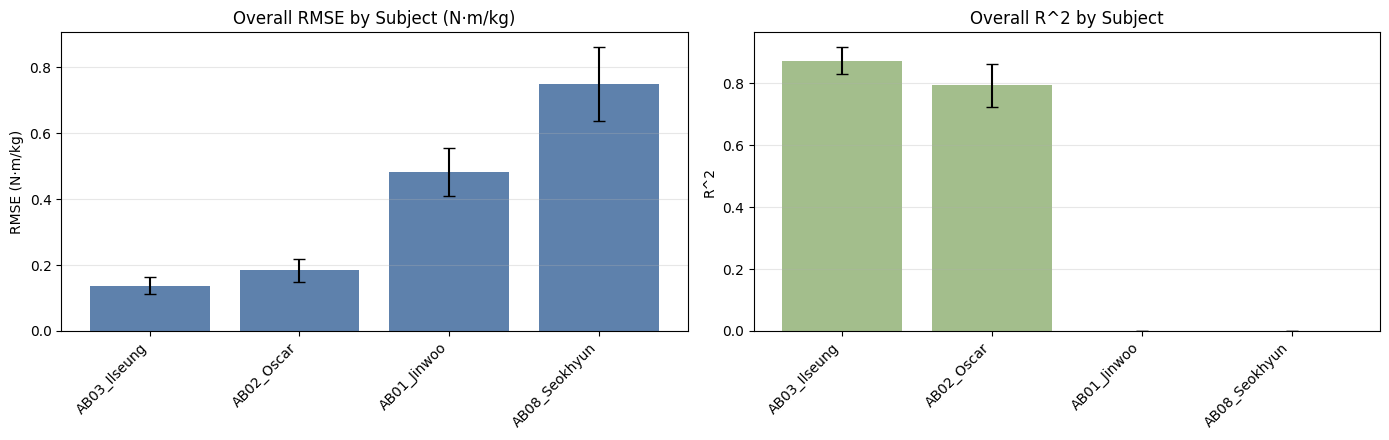

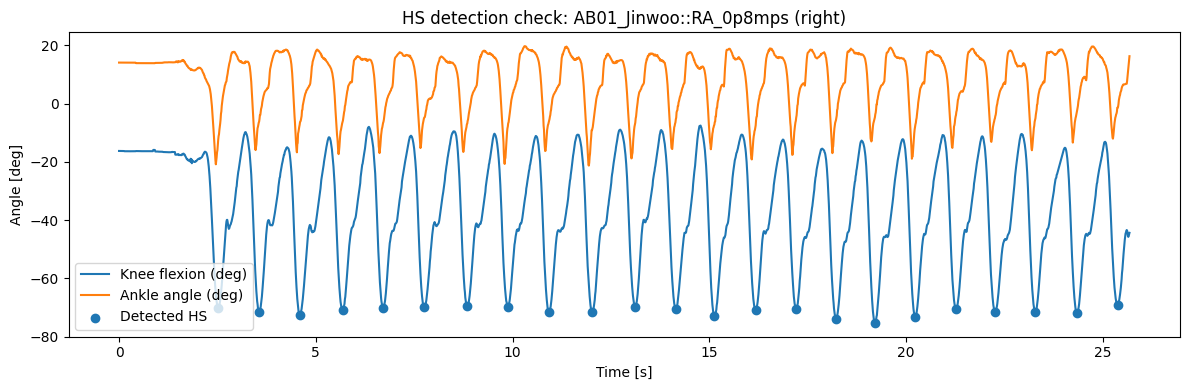

Extracted cycles: 1455 joint-side-cycle rows


,trial,subject,side,joint,cycle_idx,cycle_len_s,rmse_nmpkg,r2_nmpkg
0,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,right,hip,0,1.04,0.354491,0.025943
1,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,right,knee,0,1.04,0.855531,0.003874
2,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,right,ankle,0,1.04,0.781982,0.180494
3,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,right,hip,1,1.04,0.375539,0.000285
4,AB01_Jinwoo::RA_0p8mps,AB01_Jinwoo,right,knee,1,1.04,0.670784,0.004102


/tmp/ipykernel_1094081/1940419653.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, j].boxplot([d_r, d_l], labels=['R', 'L'], showfliers=False)
/tmp/ipykernel_1094081/1940419653.py:195: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[1, j].boxplot([d_r2_r, d_r2_l], labels=['R', 'L'], showfliers=False)
/tmp/ipykernel_1094081/1940419653.py:189: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axs[0, j].boxplot([d_r, d_l], labels=['R', 'L'], showfliers=False)
/tmp/ipykernel_1094081/1940419653.py:195: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotli

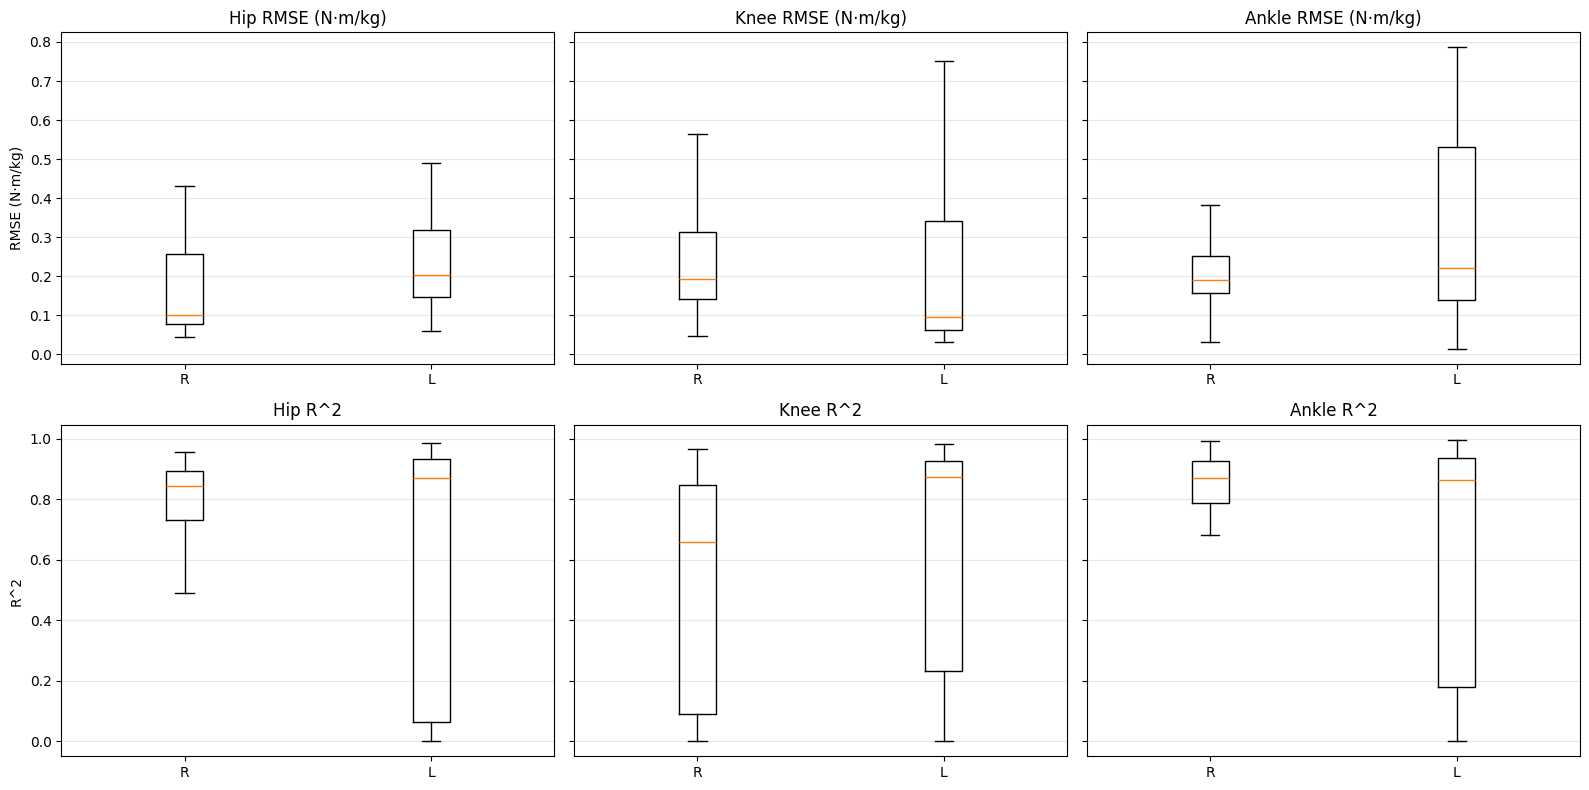

Cycle-level subject summary:


,subject,rmse_mean,rmse_sd,r2_mean,r2_sd,n_cycles
2,AB03_Ilseung,0.128321,0.075142,0.848089,0.125192,537
1,AB02_Oscar,0.181318,0.082923,0.792837,0.242714,591
0,AB01_Jinwoo,0.516015,0.197103,0.092494,0.103522,168
3,AB08_Seokhyun,0.678295,0.144418,0.050194,0.072698,159


In [13]:
# --- Subject overall plots + joint-side boxplots using HS-segmented gait cycles ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if 'TRIAL_DATA' not in globals() or not TRIAL_DATA:
    raise RuntimeError('TRIAL_DATA is empty. Run evaluation cells first.')

# Ensure we have a trial-level summary table.
if 'summary_df' in globals() and isinstance(summary_df, pd.DataFrame) and len(summary_df) > 0:
    _summary_local = summary_df.copy()
else:
    rows = []
    for trial, d in TRIAL_DATA.items():
        metrics = d.get('metrics', [])
        rows.append({
            'trial': trial,
            'subject': d.get('subject', 'unknown'),
            'mean_rmse_nmpkg': float(np.nanmean([m.get('rmse_nmpkg', np.nan) for m in metrics])),
            'mean_r2_nmpkg': float(np.nanmean([m.get('r2_nmpkg', np.nan) for m in metrics])),
        })
    _summary_local = pd.DataFrame(rows)

# 1) Overall RMSE / R^2 for each subject (mean +/- SD across that subject's trials)
subj_overall = (
    _summary_local
    .groupby('subject')
    .agg(
        rmse_mean=('mean_rmse_nmpkg', 'mean'),
        rmse_sd=('mean_rmse_nmpkg', 'std'),
        r2_mean=('mean_r2_nmpkg', 'mean'),
        r2_sd=('mean_r2_nmpkg', 'std'),
        n_trials=('trial', 'count') if 'trial' in _summary_local.columns else ('mean_rmse_nmpkg', 'count'),
    )
    .reset_index()
    .sort_values('rmse_mean')
)

display(subj_overall)

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5), sharex=True)
x = np.arange(len(subj_overall))
labels = subj_overall['subject'].tolist()

axs[0].bar(x, subj_overall['rmse_mean'], yerr=subj_overall['rmse_sd'].fillna(0.0), capsize=4, color='#5e81ac')
axs[0].set_title('Overall RMSE by Subject (N·m/kg)')
axs[0].set_ylabel('RMSE (N·m/kg)')
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels, rotation=45, ha='right')
axs[0].grid(axis='y', alpha=0.3)

axs[1].bar(x, subj_overall['r2_mean'], yerr=subj_overall['r2_sd'].fillna(0.0), capsize=4, color='#a3be8c')
axs[1].set_title('Overall R^2 by Subject')
axs[1].set_ylabel('R^2')
axs[1].set_ylim(bottom=0)
axs[1].set_xticks(x)
axs[1].set_xticklabels(labels, rotation=45, ha='right')
axs[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# 2) HS-to-HS segmentation and cycle-level metrics

def _infer_fs_from_t(t):
    t = np.asarray(t, dtype=float)
    if t.size < 3:
        return np.nan
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 1e-9)]
    if dt.size == 0:
        return np.nan
    return float(1.0 / np.median(dt))

joint_to_moment_col = {
    ('hip', 'right'): 'hip_flexion_r_moment',
    ('knee', 'right'): 'knee_angle_r_moment',
    ('ankle', 'right'): 'ankle_angle_r_moment',
    ('hip', 'left'): 'hip_flexion_l_moment',
    ('knee', 'left'): 'knee_angle_l_moment',
    ('ankle', 'left'): 'ankle_angle_l_moment',
}

ik_angle_col = {
    ('hip', 'right'): 'hip_flexion_r',
    ('knee', 'right'): 'knee_angle_r',
    ('ankle', 'right'): 'ankle_angle_r',
    ('hip', 'left'): 'hip_flexion_l',
    ('knee', 'left'): 'knee_angle_l',
    ('ankle', 'left'): 'ankle_angle_l',
}

# Resolve required indices once.
missing_ik = [name for name in ik_angle_col.values() if name not in IK_DOF_NAMES]
if missing_ik:
    raise RuntimeError(f'Missing IK channels in IK_DOF_NAMES: {missing_ik}')

if 'ID_COLS' not in globals():
    raise RuntimeError('ID_COLS not found. Run model/eval setup cells first.')

moment_idx = {name: ID_COLS.index(name) for name in joint_to_moment_col.values() if name in ID_COLS}
missing_mom = [name for name in joint_to_moment_col.values() if name not in moment_idx]
if missing_mom:
    raise RuntimeError(f'Missing moment channels in ID_COLS: {missing_mom}')

ik_idx = {name: IK_DOF_NAMES.index(name) for name in ik_angle_col.values()}

cycle_rows = []
hs_debug_done = False
for trial_key, d in TRIAL_DATA.items():
    t = np.asarray(d['t'], dtype=float)
    fs = _infer_fs_from_t(t)
    if not np.isfinite(fs):
        continue

    # Use mocap IK for segmentation stability.
    ik = np.asarray(d['mocap_ik_rad'], dtype=float)
    pred = np.asarray(d['pred_nmpkg'], dtype=float)
    ref = np.asarray(d['id_nmpkg'], dtype=float)

    for side_name, side in [('right', 'r'), ('left', 'l')]:
        knee_deg = np.rad2deg(ik[:, ik_idx[f'knee_angle_{side}']])
        ankle_deg = np.rad2deg(ik[:, ik_idx[f'ankle_angle_{side}']])
        hip_deg = np.rad2deg(ik[:, ik_idx[f'hip_flexion_{side}']])

        hs_events = detect_hs_knee_ankle(
            knee_angle=knee_deg,
            ankle_angle=ankle_deg,
            fs=fs,
        )

        if len(hs_events) < 2:
            continue

        cycles = segment_hs_to_hs(hip_deg, knee_deg, ankle_deg, hs_events, fs=fs)

        # One quick visual check for first processed side/trial.
        if not hs_debug_done:
            tt = np.arange(len(knee_deg)) / fs
            plt.figure(figsize=(12, 4))
            plt.plot(tt, knee_deg, label='Knee flexion (deg)')
            plt.plot(tt, ankle_deg, label='Ankle angle (deg)')
            plt.scatter(tt[hs_events], knee_deg[hs_events], label='Detected HS', zorder=3)
            plt.title(f'HS detection check: {trial_key} ({side_name})')
            plt.xlabel('Time [s]')
            plt.ylabel('Angle [deg]')
            plt.legend()
            plt.tight_layout()
            plt.show()
            hs_debug_done = True

        for cyc_i, cyc in enumerate(cycles):
            s0 = int(cyc['start_idx'])
            s1 = int(cyc['end_idx'])
            if s1 <= s0:
                continue

            for joint in ('hip', 'knee', 'ankle'):
                mcol = joint_to_moment_col[(joint, side_name)]
                cidx = moment_idx[mcol]
                rmse, r2 = _compute_rmse_r2(pred[s0:s1, cidx], ref[s0:s1, cidx])
                cycle_rows.append({
                    'trial': trial_key,
                    'subject': d.get('subject', 'unknown'),
                    'side': side_name,
                    'joint': joint,
                    'cycle_idx': cyc_i,
                    'cycle_len_s': (s1 - s0) / fs,
                    'rmse_nmpkg': rmse,
                    'r2_nmpkg': r2,
                })

cycle_df = pd.DataFrame(cycle_rows)
if cycle_df.empty:
    raise RuntimeError('No gait cycles were extracted. Check IK channels / HS parameters.')

print(f'Extracted cycles: {len(cycle_df)} joint-side-cycle rows')
display(cycle_df.head())

# 3) Box plots per joint with separate right/left distributions
joints = ['hip', 'knee', 'ankle']

fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharey='row')
for j, joint in enumerate(joints):
    d_r = cycle_df[(cycle_df['joint'] == joint) & (cycle_df['side'] == 'right')]['rmse_nmpkg'].dropna().to_numpy()
    d_l = cycle_df[(cycle_df['joint'] == joint) & (cycle_df['side'] == 'left')]['rmse_nmpkg'].dropna().to_numpy()
    axs[0, j].boxplot([d_r, d_l], labels=['R', 'L'], showfliers=False)
    axs[0, j].set_title(f'{joint.capitalize()} RMSE (N·m/kg)')
    axs[0, j].grid(axis='y', alpha=0.3)

    d_r2_r = cycle_df[(cycle_df['joint'] == joint) & (cycle_df['side'] == 'right')]['r2_nmpkg'].dropna().to_numpy()
    d_r2_l = cycle_df[(cycle_df['joint'] == joint) & (cycle_df['side'] == 'left')]['r2_nmpkg'].dropna().to_numpy()
    axs[1, j].boxplot([d_r2_r, d_r2_l], labels=['R', 'L'], showfliers=False)
    axs[1, j].set_title(f'{joint.capitalize()} R^2')
    axs[1, j].grid(axis='y', alpha=0.3)

axs[0, 0].set_ylabel('RMSE (N·m/kg)')
axs[1, 0].set_ylabel('R^2')
plt.tight_layout()
plt.show()

# Optional: per-subject cycle-level summary
subj_cycle = (
    cycle_df.groupby('subject')
    .agg(
        rmse_mean=('rmse_nmpkg', 'mean'),
        rmse_sd=('rmse_nmpkg', 'std'),
        r2_mean=('r2_nmpkg', 'mean'),
        r2_sd=('r2_nmpkg', 'std'),
        n_cycles=('cycle_idx', 'count'),
    )
    .reset_index()
    .sort_values('rmse_mean')
)
print('Cycle-level subject summary:')
display(subj_cycle)


Normalized cycles used: 485


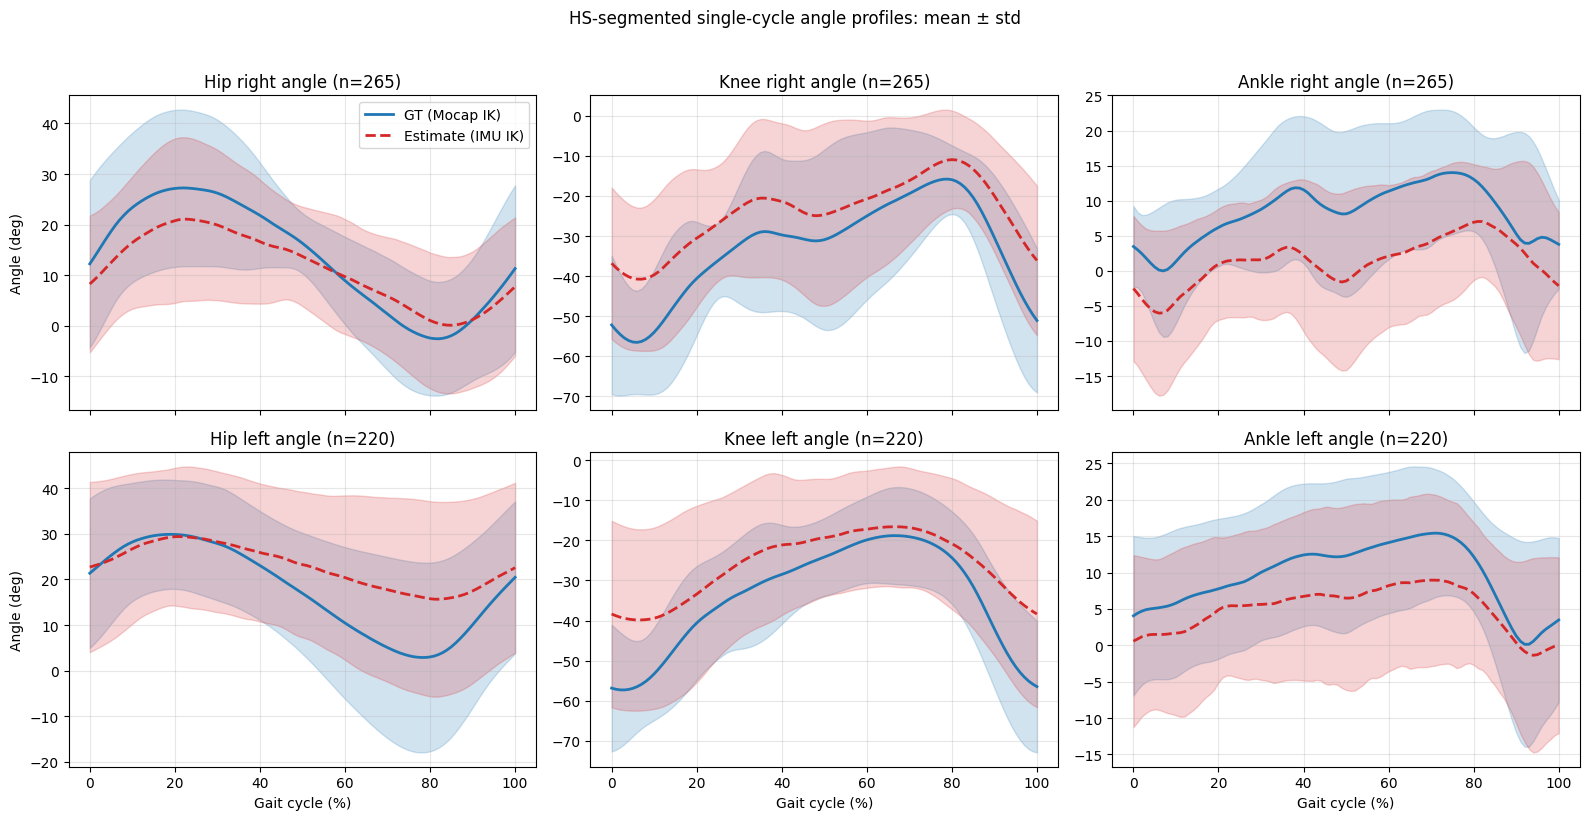

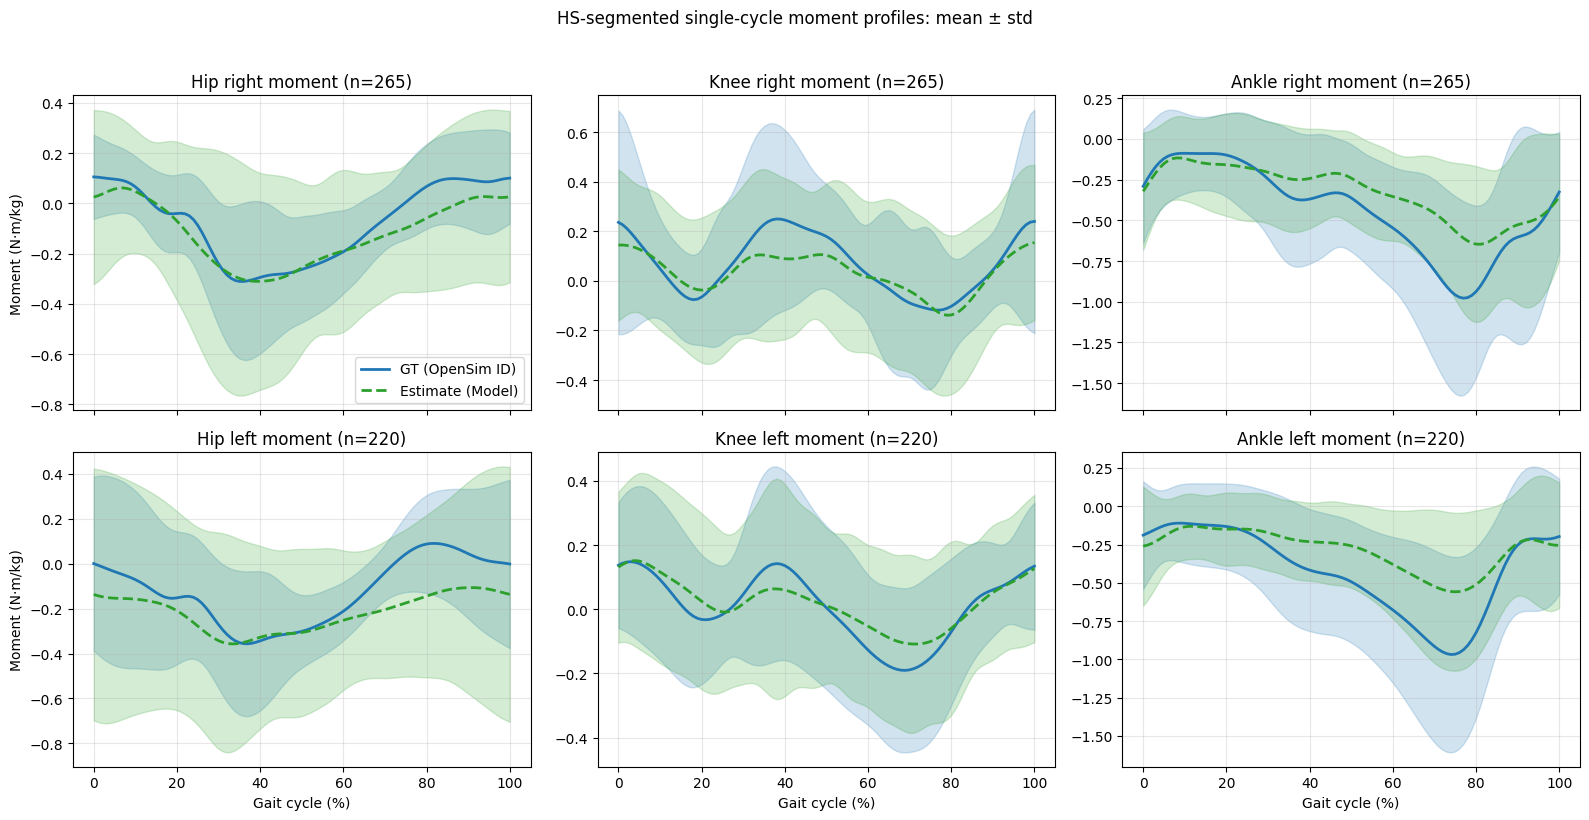

In [14]:
# --- Mean ± std over one normalized gait cycle (GT vs estimate) ---
# Uses HS-to-HS segmentation from detect_hs_knee_ankle / segment_hs_to_hs.

import numpy as np
import matplotlib.pyplot as plt

if 'TRIAL_DATA' not in globals() or not TRIAL_DATA:
    raise RuntimeError('TRIAL_DATA is empty. Run evaluation cells first.')
if 'detect_hs_knee_ankle' not in globals() or 'segment_hs_to_hs' not in globals():
    raise RuntimeError('Segmentation utilities are missing. Run the gait-cycle utility cell first.')
if 'IK_DOF_NAMES' not in globals() or 'ID_COLS' not in globals():
    raise RuntimeError('IK_DOF_NAMES / ID_COLS missing. Run model/eval setup cells first.')


def _infer_fs_from_t(t):
    t = np.asarray(t, dtype=float)
    if t.size < 3:
        return np.nan
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 1e-9)]
    if dt.size == 0:
        return np.nan
    return float(1.0 / np.median(dt))


def _resample_to_percent(x, n=101):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return None
    src = np.linspace(0.0, 100.0, x.size)
    dst = np.linspace(0.0, 100.0, n)
    good = np.isfinite(x)
    if good.sum() < 2:
        return None
    return np.interp(dst, src[good], x[good])


def _stack_stats(arr_list):
    if len(arr_list) == 0:
        return None, None
    A = np.vstack(arr_list)
    return np.nanmean(A, axis=0), np.nanstd(A, axis=0)

# Mapping
joints = ['hip', 'knee', 'ankle']
sides = [('right', 'r'), ('left', 'l')]

ik_col = {
    ('hip', 'right'): 'hip_flexion_r',
    ('knee', 'right'): 'knee_angle_r',
    ('ankle', 'right'): 'ankle_angle_r',
    ('hip', 'left'): 'hip_flexion_l',
    ('knee', 'left'): 'knee_angle_l',
    ('ankle', 'left'): 'ankle_angle_l',
}

mom_col = {
    ('hip', 'right'): 'hip_flexion_r_moment',
    ('knee', 'right'): 'knee_angle_r_moment',
    ('ankle', 'right'): 'ankle_angle_r_moment',
    ('hip', 'left'): 'hip_flexion_l_moment',
    ('knee', 'left'): 'knee_angle_l_moment',
    ('ankle', 'left'): 'ankle_angle_l_moment',
}

ik_idx = {k: IK_DOF_NAMES.index(v) for k, v in ik_col.items()}
mom_idx = {k: ID_COLS.index(v) for k, v in mom_col.items()}

# Collect normalized cycles
angle_gt_cycles = {(j, s): [] for j in joints for s, _ in [('right', 'r'), ('left', 'l')]}
angle_est_cycles = {(j, s): [] for j in joints for s, _ in [('right', 'r'), ('left', 'l')]}
mom_gt_cycles = {(j, s): [] for j in joints for s, _ in [('right', 'r'), ('left', 'l')]}
mom_est_cycles = {(j, s): [] for j in joints for s, _ in [('right', 'r'), ('left', 'l')]}

n_cycles_total = 0
for trial_key, d in TRIAL_DATA.items():
    t = np.asarray(d['t'], dtype=float)
    fs = _infer_fs_from_t(t)
    if not np.isfinite(fs):
        continue

    mocap_ik = np.asarray(d['mocap_ik_rad'], dtype=float)
    imu_ik = np.asarray(d['imu_ik_rad'], dtype=float)
    gt_m = np.asarray(d['id_nmpkg'], dtype=float)
    est_m = np.asarray(d['pred_nmpkg'], dtype=float)

    for side_name, side_short in sides:
        knee_deg = np.rad2deg(mocap_ik[:, ik_idx[('knee', side_name)]])
        ankle_deg = np.rad2deg(mocap_ik[:, ik_idx[('ankle', side_name)]])
        hip_deg = np.rad2deg(mocap_ik[:, ik_idx[('hip', side_name)]])

        hs_events = detect_hs_knee_ankle(
            knee_angle=knee_deg,
            ankle_angle=ankle_deg,
            fs=fs,
        )

        cycles = segment_hs_to_hs(hip_deg, knee_deg, ankle_deg, hs_events, fs=fs)
        if len(cycles) == 0:
            continue

        for cyc in cycles:
            s0 = int(cyc['start_idx'])
            s1 = int(cyc['end_idx'])
            if s1 - s0 < 5:
                continue
            n_cycles_total += 1

            for joint in joints:
                # Angles (deg): GT=mocap IK, estimate=IMU IK
                gt_ang = np.rad2deg(mocap_ik[s0:s1, ik_idx[(joint, side_name)]])
                est_ang = np.rad2deg(imu_ik[s0:s1, ik_idx[(joint, side_name)]])
                gt_ang_n = _resample_to_percent(gt_ang)
                est_ang_n = _resample_to_percent(est_ang)
                if gt_ang_n is not None and est_ang_n is not None:
                    angle_gt_cycles[(joint, side_name)].append(gt_ang_n)
                    angle_est_cycles[(joint, side_name)].append(est_ang_n)

                # Moments (N·m/kg): GT=ID, estimate=model pred
                gt_mom = gt_m[s0:s1, mom_idx[(joint, side_name)]]
                est_mom = est_m[s0:s1, mom_idx[(joint, side_name)]]
                gt_mom_n = _resample_to_percent(gt_mom)
                est_mom_n = _resample_to_percent(est_mom)
                if gt_mom_n is not None and est_mom_n is not None:
                    mom_gt_cycles[(joint, side_name)].append(gt_mom_n)
                    mom_est_cycles[(joint, side_name)].append(est_mom_n)

if n_cycles_total == 0:
    raise RuntimeError('No valid HS-to-HS cycles found. Check data and HS parameters.')

print(f'Normalized cycles used: {n_cycles_total}')
xp = np.linspace(0, 100, 101)

# --- Plot angles ---
fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for r, side_name in enumerate(['right', 'left']):
    for c, joint in enumerate(joints):
        ax = axs[r, c]
        gt_mu, gt_sd = _stack_stats(angle_gt_cycles[(joint, side_name)])
        est_mu, est_sd = _stack_stats(angle_est_cycles[(joint, side_name)])

        if gt_mu is not None:
            ax.plot(xp, gt_mu, color='#1f77b4', lw=2.0, label='GT (Mocap IK)')
            ax.fill_between(xp, gt_mu - gt_sd, gt_mu + gt_sd, color='#1f77b4', alpha=0.20)
        if est_mu is not None:
            ax.plot(xp, est_mu, color='#d62728', lw=2.0, ls='--', label='Estimate (IMU IK)')
            ax.fill_between(xp, est_mu - est_sd, est_mu + est_sd, color='#d62728', alpha=0.20)

        n_use = len(angle_gt_cycles[(joint, side_name)])
        ax.set_title(f'{joint.capitalize()} {side_name} angle (n={n_use})')
        ax.grid(alpha=0.3)
        if c == 0:
            ax.set_ylabel('Angle (deg)')
        if r == 1:
            ax.set_xlabel('Gait cycle (%)')
        if r == 0 and c == 0:
            ax.legend(loc='best')

fig.suptitle('HS-segmented single-cycle angle profiles: mean ± std', y=1.02)
fig.tight_layout()
plt.show()

# --- Plot moments ---
fig, axs = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
for r, side_name in enumerate(['right', 'left']):
    for c, joint in enumerate(joints):
        ax = axs[r, c]
        gt_mu, gt_sd = _stack_stats(mom_gt_cycles[(joint, side_name)])
        est_mu, est_sd = _stack_stats(mom_est_cycles[(joint, side_name)])

        if gt_mu is not None:
            ax.plot(xp, gt_mu, color='#1f77b4', lw=2.0, label='GT (OpenSim ID)')
            ax.fill_between(xp, gt_mu - gt_sd, gt_mu + gt_sd, color='#1f77b4', alpha=0.20)
        if est_mu is not None:
            ax.plot(xp, est_mu, color='#2ca02c', lw=2.0, ls='--', label='Estimate (Model)')
            ax.fill_between(xp, est_mu - est_sd, est_mu + est_sd, color='#2ca02c', alpha=0.20)

        n_use = len(mom_gt_cycles[(joint, side_name)])
        ax.set_title(f'{joint.capitalize()} {side_name} moment (n={n_use})')
        ax.grid(alpha=0.3)
        if c == 0:
            ax.set_ylabel('Moment (N·m/kg)')
        if r == 1:
            ax.set_xlabel('Gait cycle (%)')
        if r == 0 and c == 0:
            ax.legend(loc='best')

fig.suptitle('HS-segmented single-cycle moment profiles: mean ± std', y=1.02)
fig.tight_layout()
plt.show()


In [16]:
# --- Interactive per-subject gait-cycle plots (mean ± std), with trial swap ---

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

if 'TRIAL_DATA' not in globals() or not TRIAL_DATA:
    raise RuntimeError('TRIAL_DATA is empty. Run evaluation cells first.')
if 'detect_hs_knee_ankle' not in globals() or 'segment_hs_to_hs' not in globals():
    raise RuntimeError('Segmentation utilities are missing. Run the gait-cycle utility cell first.')
if 'IK_DOF_NAMES' not in globals() or 'ID_COLS' not in globals():
    raise RuntimeError('IK_DOF_NAMES / ID_COLS missing. Run setup/eval cells first.')


def _infer_fs_from_t(t):
    t = np.asarray(t, dtype=float)
    if t.size < 3:
        return np.nan
    dt = np.diff(t)
    dt = dt[np.isfinite(dt) & (dt > 1e-9)]
    if dt.size == 0:
        return np.nan
    return float(1.0 / np.median(dt))


def _resample_to_percent(x, n=101):
    x = np.asarray(x, dtype=float)
    if x.size < 2:
        return None
    src = np.linspace(0.0, 100.0, x.size)
    dst = np.linspace(0.0, 100.0, n)
    good = np.isfinite(x)
    if good.sum() < 2:
        return None
    return np.interp(dst, src[good], x[good])


def _stack_stats(arr_list):
    if len(arr_list) == 0:
        return None, None
    A = np.vstack(arr_list)
    return np.nanmean(A, axis=0), np.nanstd(A, axis=0)


joints = ['hip', 'knee', 'ankle']
side_map = {'right': 'r', 'left': 'l'}

ik_col = {
    ('hip', 'right'): 'hip_flexion_r',
    ('knee', 'right'): 'knee_angle_r',
    ('ankle', 'right'): 'ankle_angle_r',
    ('hip', 'left'): 'hip_flexion_l',
    ('knee', 'left'): 'knee_angle_l',
    ('ankle', 'left'): 'ankle_angle_l',
}
mom_col = {
    ('hip', 'right'): 'hip_flexion_r_moment',
    ('knee', 'right'): 'knee_angle_r_moment',
    ('ankle', 'right'): 'ankle_angle_r_moment',
    ('hip', 'left'): 'hip_flexion_l_moment',
    ('knee', 'left'): 'knee_angle_l_moment',
    ('ankle', 'left'): 'ankle_angle_l_moment',
}

ik_idx = {k: IK_DOF_NAMES.index(v) for k, v in ik_col.items()}
mom_idx = {k: ID_COLS.index(v) for k, v in mom_col.items()}

# Cache trial-side normalized cycles to keep UI responsive.
_cycle_cache = {}


def _extract_trial_side_cycles(trial_key, side_name):
    cache_key = (trial_key, side_name)
    if cache_key in _cycle_cache:
        return _cycle_cache[cache_key]

    d = TRIAL_DATA[trial_key]
    t = np.asarray(d['t'], dtype=float)
    fs = _infer_fs_from_t(t)
    if not np.isfinite(fs):
        _cycle_cache[cache_key] = None
        return None

    mocap_ik = np.asarray(d['mocap_ik_rad'], dtype=float)
    imu_ik = np.asarray(d['imu_ik_rad'], dtype=float)
    gt_m = np.asarray(d['id_nmpkg'], dtype=float)
    est_m = np.asarray(d['pred_nmpkg'], dtype=float)

    knee_deg = np.rad2deg(mocap_ik[:, ik_idx[('knee', side_name)]])
    ankle_deg = np.rad2deg(mocap_ik[:, ik_idx[('ankle', side_name)]])
    hip_deg = np.rad2deg(mocap_ik[:, ik_idx[('hip', side_name)]])

    hs_events = detect_hs_knee_ankle(
        knee_angle=knee_deg,
        ankle_angle=ankle_deg,
        fs=fs,
    )
    hs_method = 'detect_hs_knee_ankle(adaptive)'

    cycles = segment_hs_to_hs(hip_deg, knee_deg, ankle_deg, hs_events, fs=fs)
    if len(cycles) == 0:
        _cycle_cache[cache_key] = None
        return None

    out = {
        'angle_gt': {(j, side_name): [] for j in joints},
        'angle_est': {(j, side_name): [] for j in joints},
        'mom_gt': {(j, side_name): [] for j in joints},
        'mom_est': {(j, side_name): [] for j in joints},
        'hs_events': hs_events,
        'hs_method': hs_method,
        'n_cycles': 0,
    }

    for cyc in cycles:
        s0 = int(cyc['start_idx'])
        s1 = int(cyc['end_idx'])
        if s1 - s0 < 5:
            continue
        out['n_cycles'] += 1
        for joint in joints:
            gt_ang = np.rad2deg(mocap_ik[s0:s1, ik_idx[(joint, side_name)]])
            est_ang = np.rad2deg(imu_ik[s0:s1, ik_idx[(joint, side_name)]])
            gt_ang_n = _resample_to_percent(gt_ang)
            est_ang_n = _resample_to_percent(est_ang)
            if gt_ang_n is not None and est_ang_n is not None:
                out['angle_gt'][(joint, side_name)].append(gt_ang_n)
                out['angle_est'][(joint, side_name)].append(est_ang_n)

            gt_mom = gt_m[s0:s1, mom_idx[(joint, side_name)]]
            est_mom = est_m[s0:s1, mom_idx[(joint, side_name)]]
            gt_mom_n = _resample_to_percent(gt_mom)
            est_mom_n = _resample_to_percent(est_mom)
            if gt_mom_n is not None and est_mom_n is not None:
                out['mom_gt'][(joint, side_name)].append(gt_mom_n)
                out['mom_est'][(joint, side_name)].append(est_mom_n)

    _cycle_cache[cache_key] = out
    return out


subjects = sorted({d.get('subject', 'unknown') for d in TRIAL_DATA.values()})
subject_to_trials = {}
for k, d in TRIAL_DATA.items():
    subject_to_trials.setdefault(d.get('subject', 'unknown'), []).append(k)
for s in subject_to_trials:
    subject_to_trials[s] = sorted(subject_to_trials[s])

subject_dd = widgets.Dropdown(options=subjects, description='Subject:')
trial_dd = widgets.Dropdown(options=[], description='Trial:')
side_dd = widgets.Dropdown(options=['both', 'right', 'left'], value='both', description='Side:')
out = widgets.Output()


def _refresh_trial_options(*_):
    subj = subject_dd.value
    opts = ['ALL'] + subject_to_trials.get(subj, [])
    prev_trial = trial_dd.value
    trial_dd.options = opts
    new_trial = prev_trial if prev_trial in opts else (opts[0] if opts else None)
    trial_dd.value = new_trial
    return prev_trial != new_trial


def _plot_for_selection(*_):
    out.clear_output(wait=True)
    with out:
        subj = subject_dd.value
        tr = trial_dd.value
        side_sel = side_dd.value
        if subj is None or tr is None:
            print('Select subject/trial.')
            return

        trial_keys = subject_to_trials.get(subj, []) if tr == 'ALL' else [tr]
        sides = ['right', 'left'] if side_sel == 'both' else [side_sel]

        agg = {
            'angle_gt': {(j, s): [] for j in joints for s in sides},
            'angle_est': {(j, s): [] for j in joints for s in sides},
            'mom_gt': {(j, s): [] for j in joints for s in sides},
            'mom_est': {(j, s): [] for j in joints for s in sides},
        }

        hs_debug_trial = None
        hs_debug_side = None
        hs_debug_events = None
        hs_debug_method = None
        n_cycles_used = 0
        skipped_trial_sides = []

        for tk in trial_keys:
            for s in sides:
                pack = _extract_trial_side_cycles(tk, s)
                if pack is None or pack['n_cycles'] == 0:
                    skipped_trial_sides.append(f'{tk}:{s}')
                    continue
                if hs_debug_trial is None:
                    hs_debug_trial = tk
                    hs_debug_side = s
                    hs_debug_events = pack['hs_events']
                    hs_debug_method = pack.get('hs_method', 'unknown')

                n_cycles_used += int(pack['n_cycles'])
                for j in joints:
                    agg['angle_gt'][(j, s)].extend(pack['angle_gt'][(j, s)])
                    agg['angle_est'][(j, s)].extend(pack['angle_est'][(j, s)])
                    agg['mom_gt'][(j, s)].extend(pack['mom_gt'][(j, s)])
                    agg['mom_est'][(j, s)].extend(pack['mom_est'][(j, s)])

        if n_cycles_used == 0:
            print('No valid gait cycles found for the current selection after fallback extraction.')
            if len(skipped_trial_sides) > 0:
                print('Skipped trial-sides:', ', '.join(skipped_trial_sides[:8]))
            return

        xp = np.linspace(0, 100, 101)

        # Optional HS check plot for current selection
        if hs_debug_trial is not None and hs_debug_events is not None:
            d = TRIAL_DATA[hs_debug_trial]
            fs = _infer_fs_from_t(d['t'])
            mocap_ik = np.asarray(d['mocap_ik_rad'], dtype=float)
            knee_deg = np.rad2deg(mocap_ik[:, ik_idx[('knee', hs_debug_side)]])
            ankle_deg = np.rad2deg(mocap_ik[:, ik_idx[('ankle', hs_debug_side)]])
            tt = np.arange(len(knee_deg)) / fs
            plt.figure(figsize=(11, 3.5))
            plt.plot(tt, knee_deg, label='Knee flexion (deg)')
            plt.plot(tt, ankle_deg, label='Ankle angle (deg)')
            plt.scatter(tt[hs_debug_events], knee_deg[hs_debug_events], label='Detected HS', zorder=3)
            plt.title(f'HS check: {hs_debug_trial} ({hs_debug_side}) | {hs_debug_method}')
            plt.xlabel('Time [s]')
            plt.ylabel('Angle [deg]')
            plt.legend()
            plt.tight_layout()
            plt.show()

        n_rows = len(sides)
        fig, axs = plt.subplots(n_rows, 3, figsize=(16, 4.0 * n_rows), sharex=True)
        if n_rows == 1:
            axs = np.asarray([axs])
        for r, s in enumerate(sides):
            for c, j in enumerate(joints):
                ax = axs[r, c]
                gt_mu, gt_sd = _stack_stats(agg['angle_gt'][(j, s)])
                est_mu, est_sd = _stack_stats(agg['angle_est'][(j, s)])
                if gt_mu is not None:
                    ax.plot(xp, gt_mu, color='#1f77b4', lw=2, label='GT (Mocap IK)')
                    ax.fill_between(xp, gt_mu - gt_sd, gt_mu + gt_sd, color='#1f77b4', alpha=0.20)
                if est_mu is not None:
                    ax.plot(xp, est_mu, color='#d62728', lw=2, ls='--', label='Estimate (IMU IK)')
                    ax.fill_between(xp, est_mu - est_sd, est_mu + est_sd, color='#d62728', alpha=0.20)
                n_use = len(agg['angle_gt'][(j, s)])
                ax.set_title(f'{j.capitalize()} {s} angle (n={n_use})')
                ax.grid(alpha=0.3)
                if c == 0:
                    ax.set_ylabel('Angle (deg)')
                if r == n_rows - 1:
                    ax.set_xlabel('Gait cycle (%)')
                if r == 0 and c == 0:
                    handles, labels = ax.get_legend_handles_labels()
                    if handles:
                        ax.legend(loc='best')
        fig.suptitle(f'Angles mean ± std | subject={subj} | trial={tr}', y=1.02)
        fig.tight_layout()
        plt.show()

        fig, axs = plt.subplots(n_rows, 3, figsize=(16, 4.0 * n_rows), sharex=True)
        if n_rows == 1:
            axs = np.asarray([axs])
        for r, s in enumerate(sides):
            for c, j in enumerate(joints):
                ax = axs[r, c]
                gt_mu, gt_sd = _stack_stats(agg['mom_gt'][(j, s)])
                est_mu, est_sd = _stack_stats(agg['mom_est'][(j, s)])
                if gt_mu is not None:
                    ax.plot(xp, gt_mu, color='#1f77b4', lw=2, label='GT (OpenSim ID)')
                    ax.fill_between(xp, gt_mu - gt_sd, gt_mu + gt_sd, color='#1f77b4', alpha=0.20)
                if est_mu is not None:
                    ax.plot(xp, est_mu, color='#2ca02c', lw=2, ls='--', label='Estimate (Model)')
                    ax.fill_between(xp, est_mu - est_sd, est_mu + est_sd, color='#2ca02c', alpha=0.20)
                n_use = len(agg['mom_gt'][(j, s)])
                ax.set_title(f'{j.capitalize()} {s} moment (n={n_use})')
                ax.grid(alpha=0.3)
                if c == 0:
                    ax.set_ylabel('Moment (N·m/kg)')
                if r == n_rows - 1:
                    ax.set_xlabel('Gait cycle (%)')
                if r == 0 and c == 0:
                    handles, labels = ax.get_legend_handles_labels()
                    if handles:
                        ax.legend(loc='best')
        fig.suptitle(f'Moments mean ± std | subject={subj} | trial={tr}', y=1.02)
        fig.tight_layout()
        plt.show()


def _on_subject_change(change):
    trial_changed = _refresh_trial_options()
    if not trial_changed:
        _plot_for_selection()


subject_dd.observe(_on_subject_change, names='value')
trial_dd.observe(_plot_for_selection, names='value')
side_dd.observe(_plot_for_selection, names='value')

_refresh_trial_options()
_plot_for_selection()

display(widgets.VBox([widgets.HBox([subject_dd, trial_dd, side_dd]), out]))
